# GANisme — 02. Visualisation des images scrapées

**Objectif** : répondre à l'étape 5 du sujet — *« Visualisez quelques images du dataset. Qu'observez-vous ?
Quelle incidence sur le pre-processing des données ? »*

Les images ont été téléchargées par `src/scrape_images.py` depuis la Web Gallery of Art (version « detail »,
400 px de grand côté). Le notebook croise ces images avec le catalogue enrichi par l'EDA (`01_eda_art_catalog`)
pour les regarder **par genre, par technique, par siècle**, isoler les **cas problématiques**, puis mesurer quelques
**statistiques visuelles** sur l'ensemble du corpus.

| § | Contenu |
|---|---|
| 1 | Chargement et couverture du scraping |
| 2 | Échantillon aléatoire |
| 3 | Les images par genre, technique et siècle |
| 4 | Quasi-doublons : les détails d'une même œuvre |
| 5 | Cas problématiques |
| 6 | Statistiques visuelles sur les 32 437 images |
| 7 | Le format réel des images |
| 8 | Démonstration : que voit le GAN en 64×64 ? |
| 9 | Synthèse : incidences sur le preprocessing |

In [1]:
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from PIL import Image, ImageOps

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 85})   # light notebook (readable on GitHub); PNG files go to reports/

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CATALOG = ROOT / "data" / "processed" / "paintings_catalog.csv"
MANIFEST = ROOT / "data" / "raw" / "images_manifest.csv"
STATS_CACHE = ROOT / "data" / "processed" / "image_stats.csv"
MEANS_CACHE = ROOT / "data" / "processed" / "mean_images.npz"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

# --- Chart style (same as notebook 01) --------------------------------------
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#f4f8fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


def fmt(n):
    # 32437 -> '32 437' (French thousands separator)
    return f"{n:,.0f}".replace(",", " ")


def short_author(a):
    # 'GOGH, Vincent van' -> 'Gogh'; 'GIOTTO di Bondone' -> 'Giotto'
    return a.split(",")[0].split(" ")[0].title()


def caption(r):
    year = f"{r.YEAR:.0f}" if pd.notna(r.YEAR) else "?"
    return f"{short_author(r.AUTHOR)}, {year}\n{r.TITLE[:28]}"


def show_grid(rows, ncols=6, title=None, cap=caption, size=2.2, row_labels=None, name=None):
    # Show a grid of images; `rows` = DataFrame (one image per row) or list of DataFrames (one per grid row).
    groups = rows if isinstance(rows, list) else [rows.iloc[i:i + ncols] for i in range(0, len(rows), ncols)]
    fig, axes = plt.subplots(len(groups), ncols, figsize=(ncols * size, len(groups) * (size + 0.45)), squeeze=False)
    for i, g in enumerate(groups):
        for j in range(ncols):
            ax = axes[i, j]
            ax.axis("off")
            if j < len(g):
                r = g.iloc[j]
                with Image.open(r.PATH) as im:
                    ax.imshow(im.convert("RGB"))
                ax.set_title(cap(r), fontsize=7.5, fontweight="normal", color=INK2, loc="center")
    if title:
        fig.suptitle(title, x=0.01, ha="left", fontsize=13, fontweight="bold")
    left = 0.035 if row_labels else 0
    plt.tight_layout(rect=(left, 0, 1, 0.97 if title else 1))
    if row_labels:  # labels placed in figure coordinates: independent of the width of the images
        for i, lbl in enumerate(row_labels):
            pos = axes[i, 0].get_position()
            fig.text(0.012, pos.y0 + pos.height / 2, lbl, rotation=90, ha="center", va="center",
                     fontsize=11, fontweight="bold", color=INK)
    if name:
        save(fig, name)
    plt.show()

## 1. Chargement et couverture du scraping

In [2]:
cat = pd.read_csv(CATALOG)
man = pd.read_csv(MANIFEST).drop_duplicates("url", keep="last")   # last attempt for each artwork
df = cat.merge(man[["url", "local_path", "status", "image_url", "width", "height", "mode", "bytes"]],
               left_on="URL", right_on="url", how="left").drop(columns="url")

print(f"Peintures au catalogue : {fmt(len(cat))}")
print("Statut du scraping      :", df["status"].value_counts().to_dict())
print(f"Poids total des images  : {df['bytes'].sum() / 1e6:.0f} Mo")
df.loc[df["status"] != "ok", ["AUTHOR", "TITLE", "URL", "image_url", "status"]]

Peintures au catalogue : 32 438
Statut du scraping      : {'ok': 32437, 'not_found': 1}
Poids total des images  : 648 Mo


,AUTHOR,TITLE,URL,image_url,status
11578,GIOTTO di Bondone,Vault,https://www.wga.hu/html/g/giotto/padova/6vault...,https://www.wga.hu/detail/g/giotto/padova/6vau...,not_found


In [3]:
imgs = df[df["status"] == "ok"].copy()
imgs["PATH"] = imgs["local_path"].map(lambda p: ROOT / p)
imgs["IMG_ASPECT"] = imgs["width"] / imgs["height"]
imgs["MIN_SIDE"] = imgs[["width", "height"]].min(axis=1)
imgs["CENTURY_LBL"] = imgs["CENTURY"].astype(int).astype(str) + "e s."
assert imgs["PATH"].map(Path.exists).all(), "image manquante sur le disque"
print(f"{fmt(len(imgs))} images disponibles")
imgs[["width", "height", "IMG_ASPECT", "MIN_SIDE", "bytes"]].describe(percentiles=[.01, .05, .5, .95]).round(2)

32 437 images disponibles


,width,height,IMG_ASPECT,MIN_SIDE,bytes
count,32437.00,32437.00,32437.00,32437.00,32437.00
mean,342.03,353.70,1.04,295.73,19973.24
std,61.26,63.97,0.42,49.76,6371.44
min,81.00,53.00,0.20,53.00,3943.00
1%,160.00,166.36,0.40,141.00,8104.36
5%,231.00,234.00,0.58,200.00,10740.80
50%,341.00,400.00,0.85,301.00,19234.00
95%,400.00,400.00,1.71,374.00,31627.00
max,400.00,400.00,7.55,400.00,54045.00


**Observations**

- Le scraping couvre **32 437 peintures sur 32 438**. L'image manquante est la voûte de la chapelle Scrovegni de Giotto
  (`…/giotto/padova/6vault/0vault.html`) : la page n'existe plus sur le site, qui renvoie sa page générique
  « adresse changée ». Le dossier contient une page `01vault.html` (« Vault fresco »), absente du catalogue et
  probablement l'œuvre renommée.
- Toutes les images font **400 px de grand côté** (version « detail » du site). Le petit côté médian est de 301 px,
  et 95 % des images ont un petit côté ≥ 200 px.

## 2. Échantillon aléatoire

Un tirage uniforme donne l'image la plus honnête de ce que verra le GAN : c'est la distribution qu'il va apprendre.

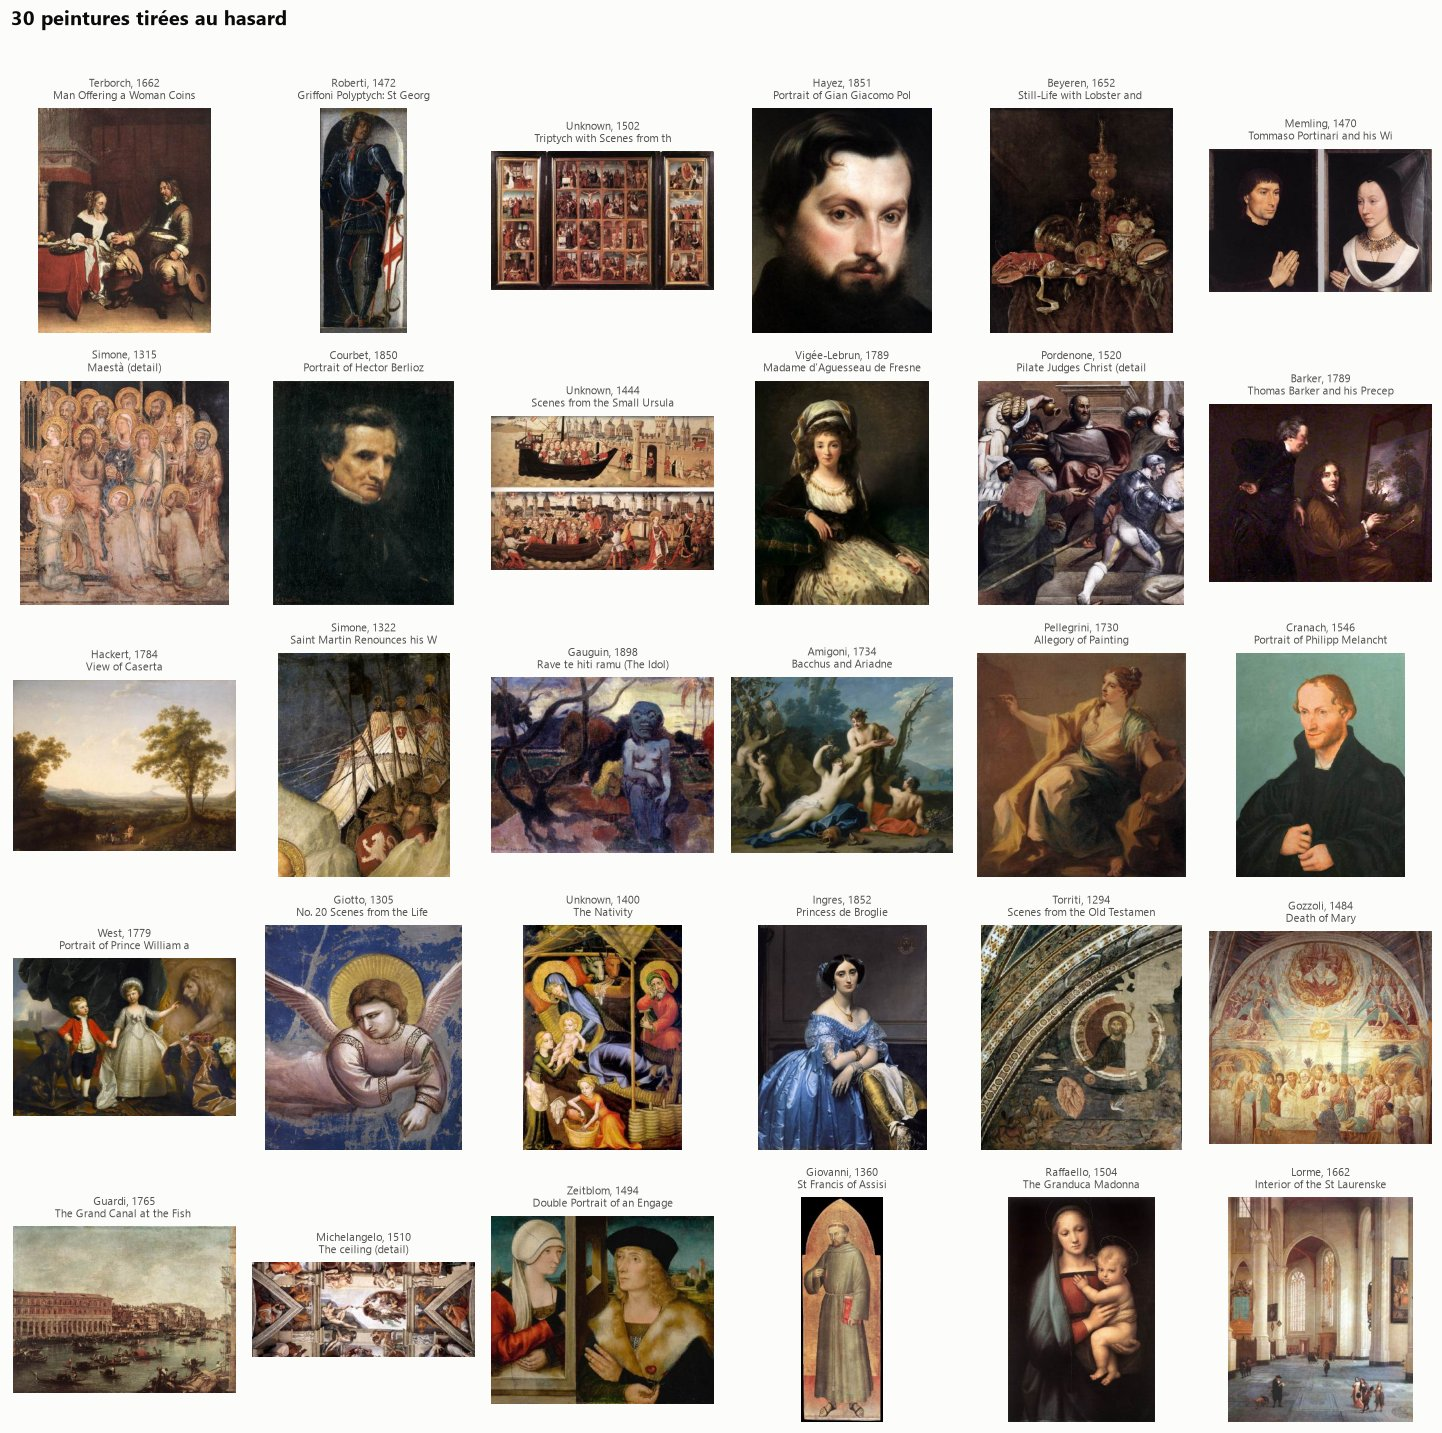

In [4]:
show_grid(imgs.sample(30, random_state=SEED), ncols=6, title="30 peintures tirées au hasard", name="img_01_random")

**Observations sur l'échantillon aléatoire** — dès 30 images, la diversité saute aux yeux, bien au-delà du
« tableau rectangulaire » idéal :

- **des objets multiples dans une seule image** : triptyques et polyptyques avec leurs cadres dorés, diptyques
  (Memling), deux panneaux superposés sur fond blanc (*Scenes from the Small Ursula*) ;
- **des détails** recadrés au milieu d'une composition plus large (Simone Martini, Pordenone, Michel-Ange) ;
- **des vues in situ** : voûtes, arcs et absides photographiés en perspective (Torriti, Gozzoli), plafond de la Sixtine ;
- **des panneaux de forme non rectangulaire** (sommet cintré, gothique) détourés sur fond blanc ou gris ;
- une dominante de **tons bruns et sombres** (vernis ancien, fonds noirs des portraits).

## 3. Les images par genre, technique et siècle

### 3.1 Par genre (`TYPE`)

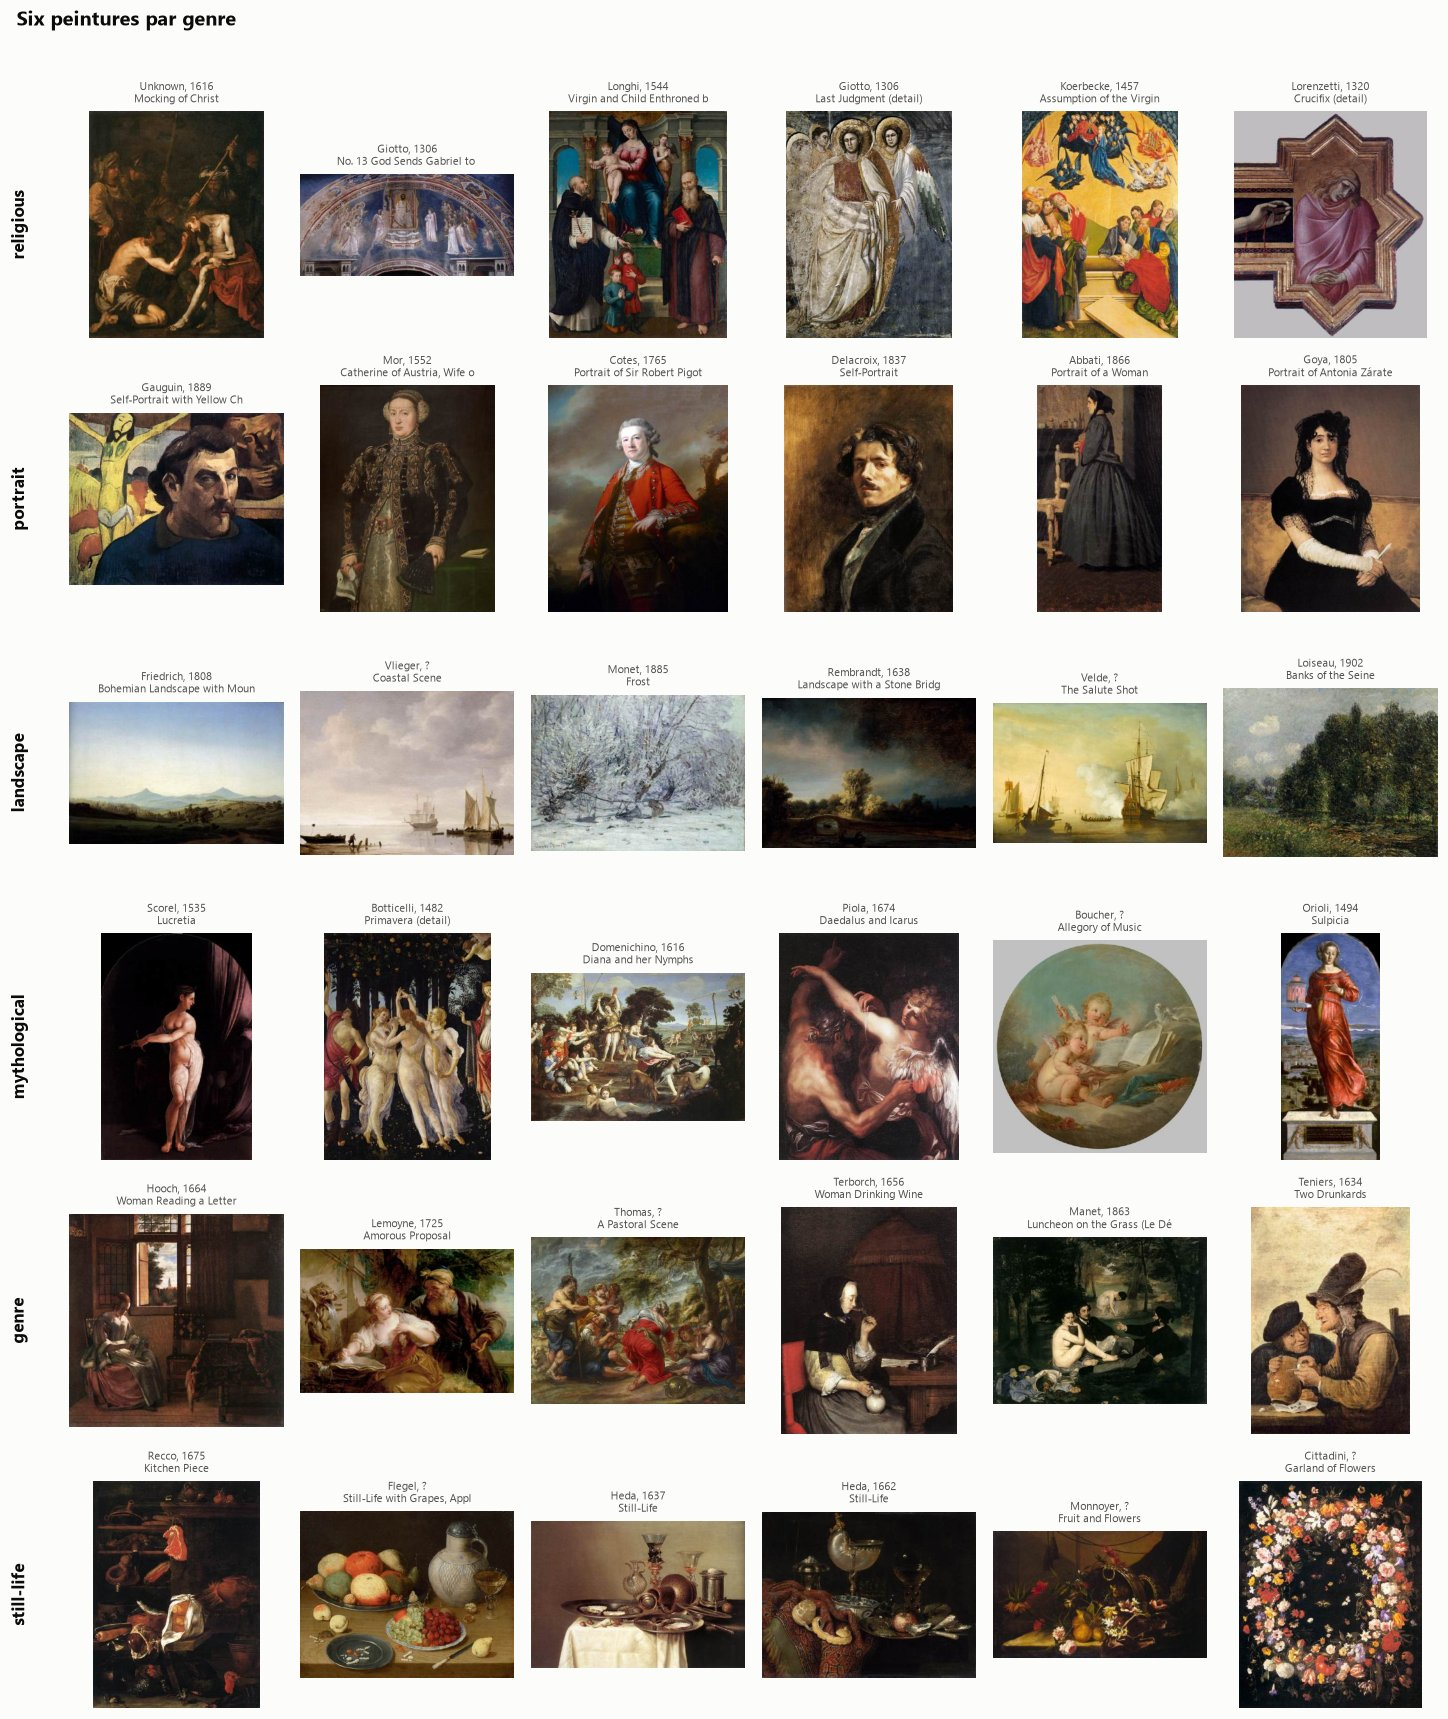

In [5]:
types = ["religious", "portrait", "landscape", "mythological", "genre", "still-life"]
groups = [imgs[imgs["TYPE"] == t].sample(6, random_state=SEED) for t in types]
show_grid(groups, row_labels=types, title="Six peintures par genre", name="img_02_by_type")

### 3.2 Par technique

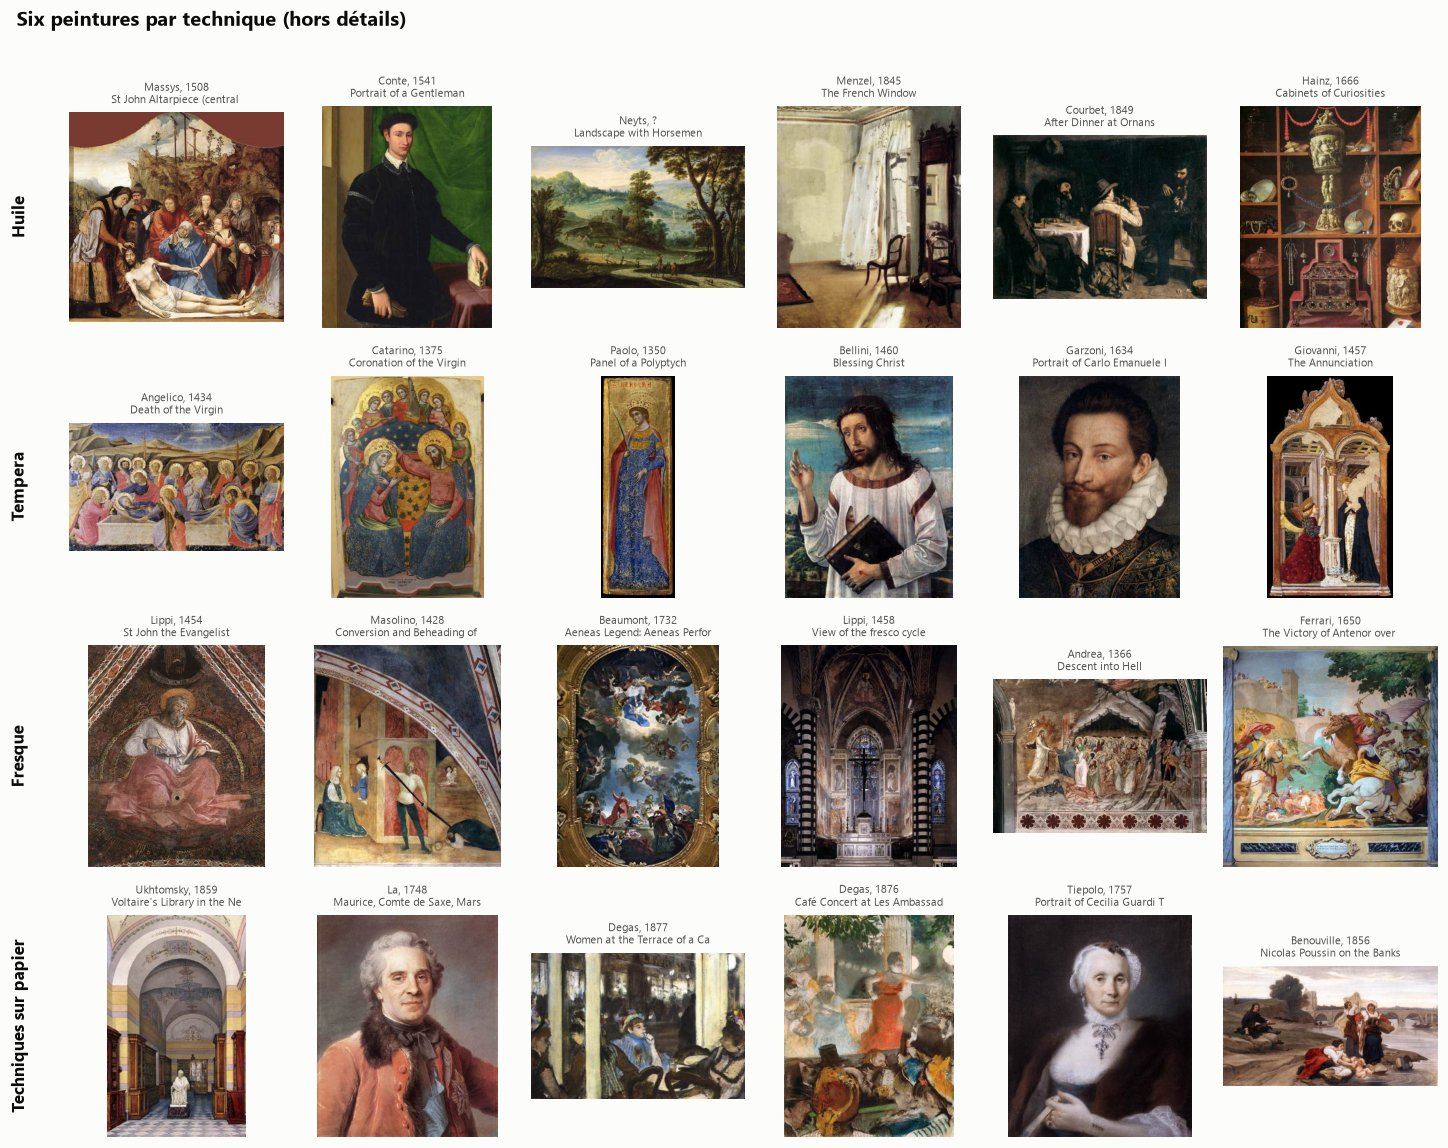

In [6]:
fams = ["Huile", "Tempera", "Fresque", "Techniques sur papier"]
groups = [imgs[(imgs["MEDIUM_FAMILY"] == f) & ~imgs["IS_DETAIL"]].sample(6, random_state=SEED) for f in fams]
show_grid(groups, row_labels=fams, title="Six peintures par technique (hors détails)", name="img_03_by_medium")

### 3.3 Par siècle

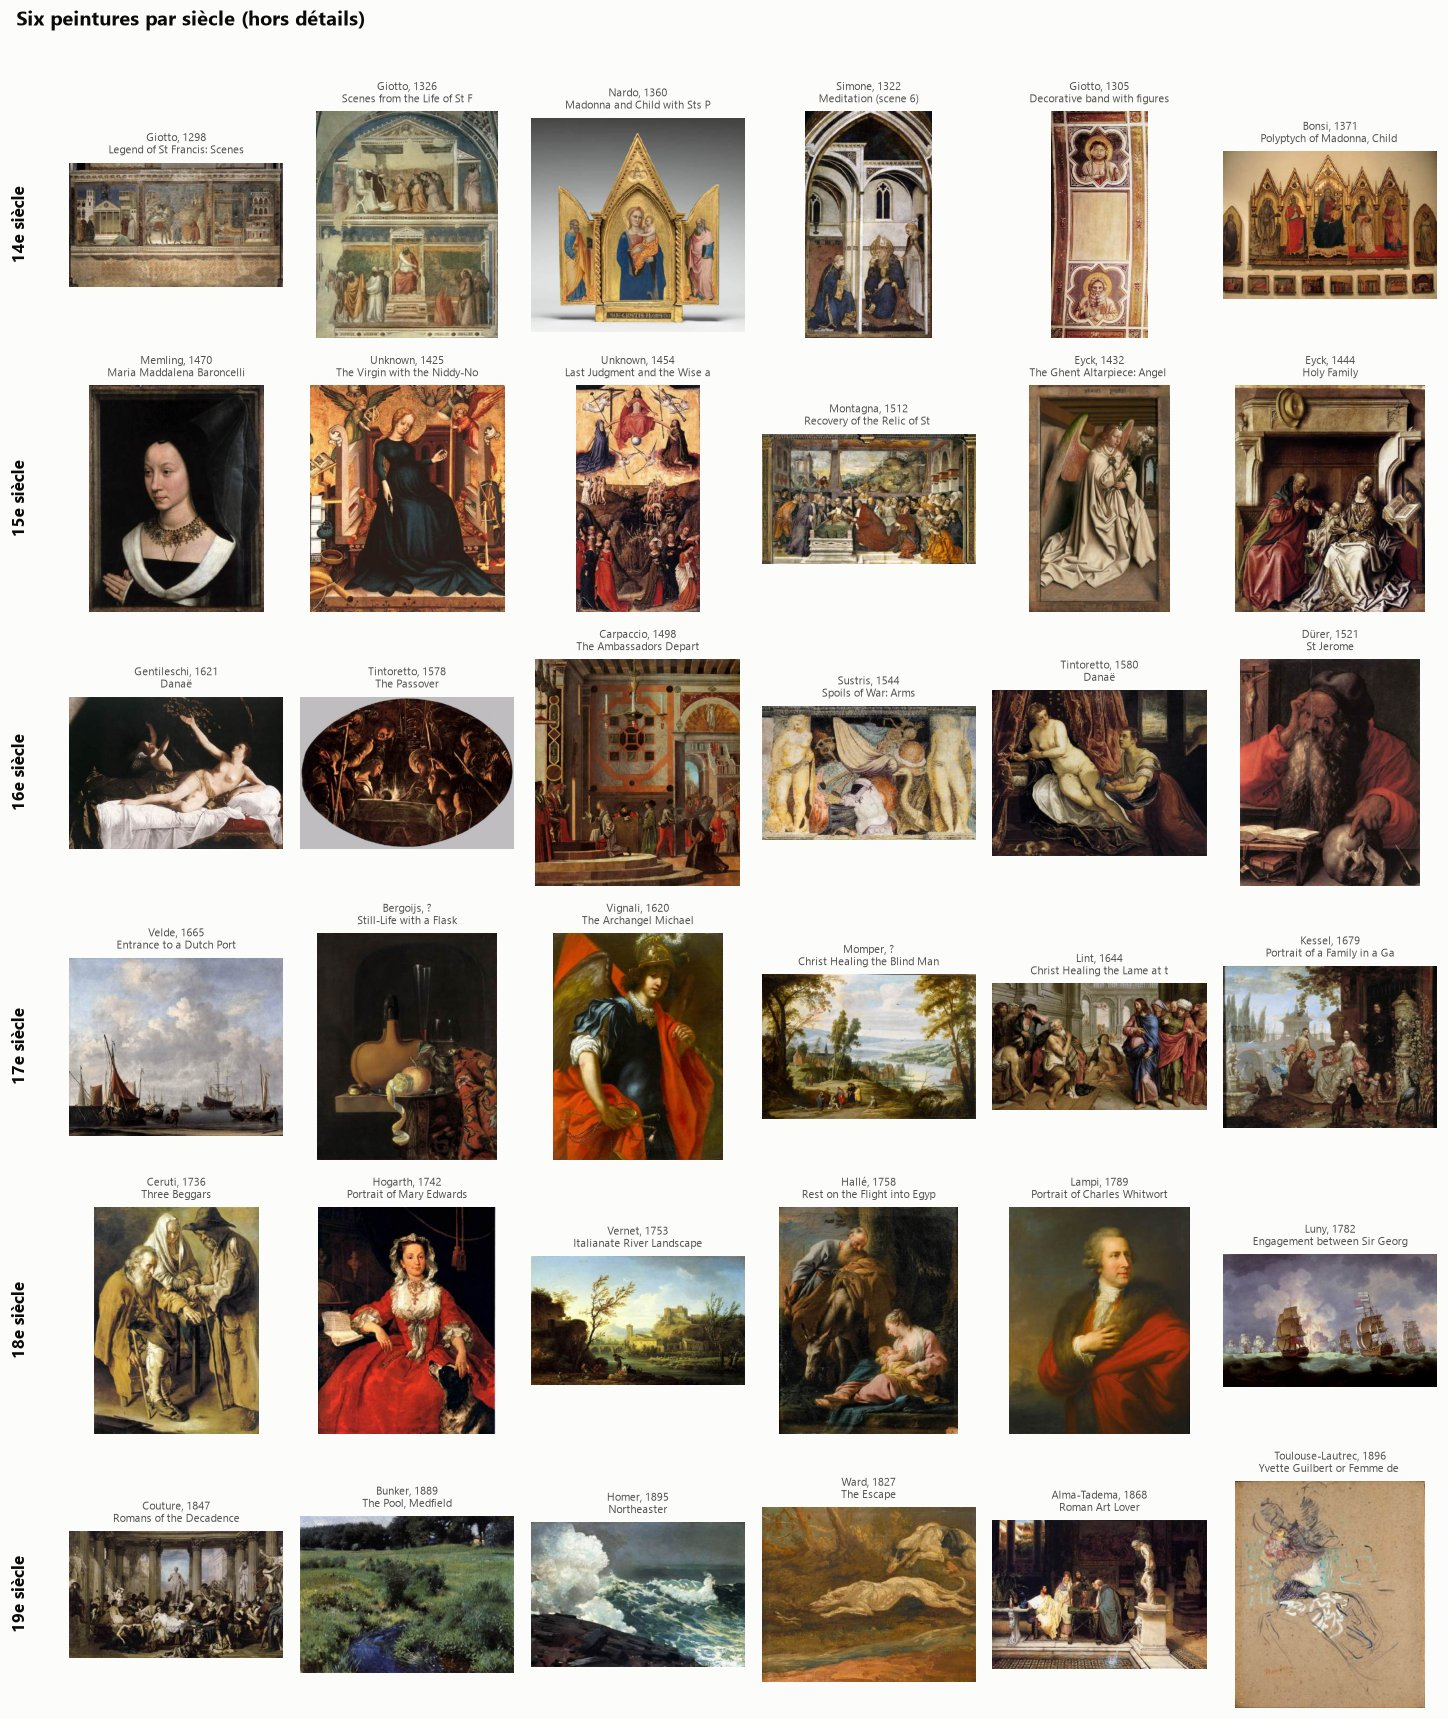

In [7]:
cents = [14, 15, 16, 17, 18, 19]
groups = [imgs[(imgs["CENTURY"] == c) & ~imgs["IS_DETAIL"]].sample(6, random_state=SEED) for c in cents]
show_grid(groups, row_labels=[f"{c}e siècle" for c in cents], title="Six peintures par siècle (hors détails)",
          name="img_04_by_century")

**Observations par genre, technique et siècle**

- **Genre** : les portraits sont très homogènes (buste centré, fond sombre, format vertical) ; les paysages aussi
  (ciel clair en haut, sol sombre en bas, format horizontal). Les natures mortes partagent un fond noir. À l'inverse,
  la catégorie **religieuse** est la plus hétérogène : lunettes de fresques, crucifix chantournés, retables gothiques,
  toiles baroques. C'est aussi la plus nombreuse.
- **Technique** : la tempera se reconnaît aux **fonds dorés** et aux cadres gothiques ; la fresque aux arcs,
  lunettes et éléments d'architecture, avec des surfaces usées ; l'huile aux fonds sombres et au vernis ; les
  techniques sur papier (pastel, dessin) sont plus claires et moins « finies ».
- **Siècle** : l'évolution est très lisible — fonds d'or et fresques au XIVᵉ, clair-obscur ténébriste au XVIIᵉ,
  palette plus claire et sujets de plein air au XIXᵉ.
- Conséquence : un GAN entraîné sur l'ensemble devra apprendre **plusieurs « langues » visuelles** très différentes.
  Avec un petit modèle (DCGAN), le risque est d'obtenir des images hybrides et boueuses ; un sous-corpus plus homogène
  (par genre ou par période) sera plus facile à apprendre.

## 4. Quasi-doublons : les détails d'une même œuvre

L'EDA a identifié 18 % de quasi-doublons. Voici à quoi ils ressemblent concrètement.

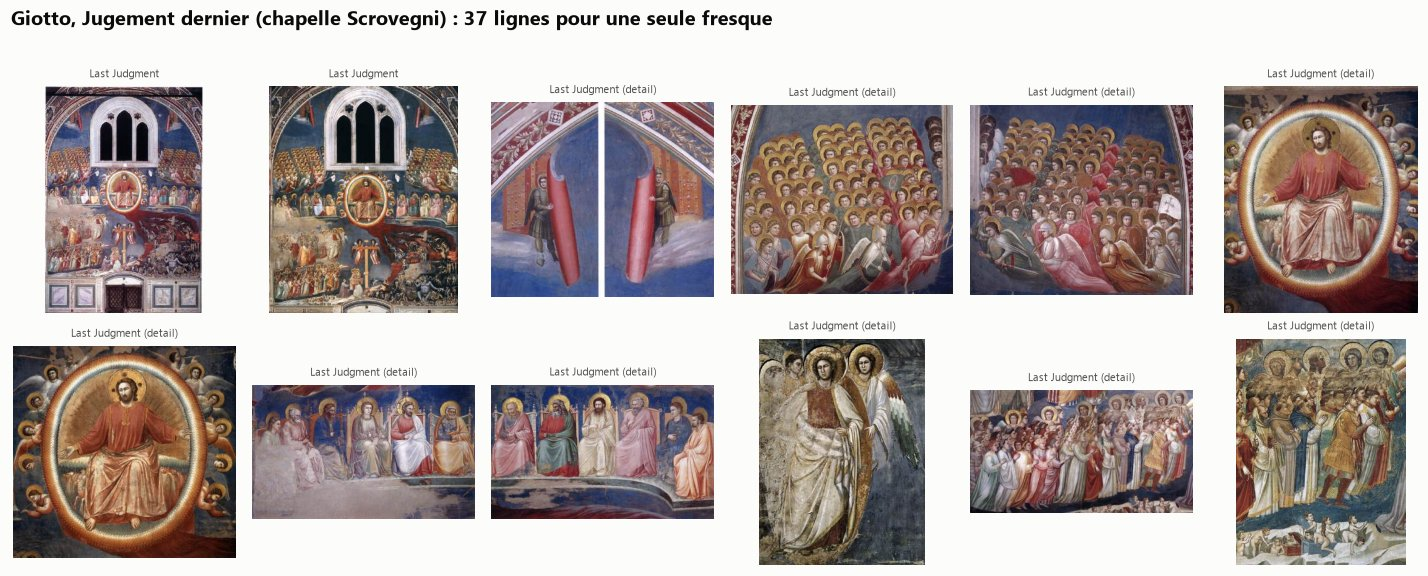

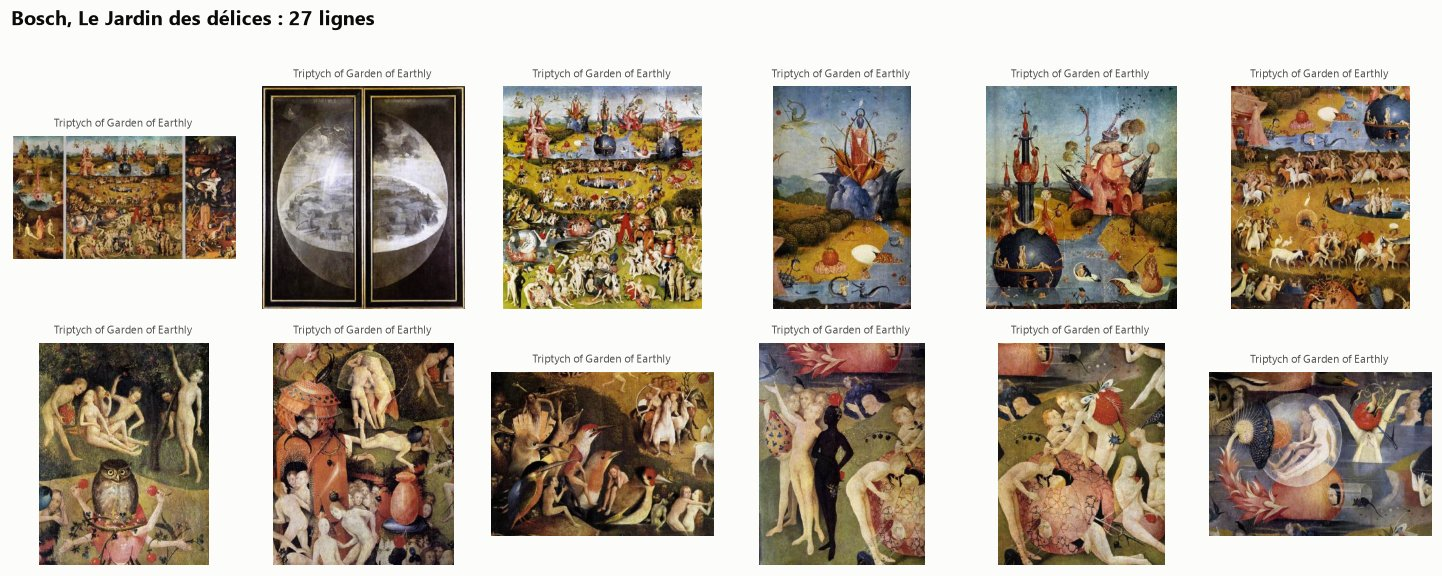

In [8]:
lj = imgs[(imgs["AUTHOR"] == "GIOTTO di Bondone") & (imgs["TITLE_BASE"] == "Last Judgment")]
show_grid(lj.head(12), ncols=6, title=f"Giotto, Jugement dernier (chapelle Scrovegni) : {len(lj)} lignes pour une seule fresque",
          cap=lambda r: r.TITLE[:30], name="img_05_details_giotto")

bosch = imgs[imgs["TITLE_BASE"].str.contains("Garden of Earthly Delights", na=False)]
show_grid(bosch.head(12), ncols=6, title=f"Bosch, Le Jardin des délices : {len(bosch)} lignes",
          cap=lambda r: r.TITLE[:30], name="img_06_details_bosch")

**Observations** — les détails ne sont pas des doublons exacts mais des **recadrages à différentes échelles d'une même
composition** : le Christ en gloire de Giotto apparaît dans la vue d'ensemble, puis en plan moyen, puis en gros plan.
Un filtre par hachage perceptuel ne les détecterait pas tous (le cadrage change) ; le **filtre par métadonnées**
(`IS_DETAIL`, `IS_NEAR_DUP` issus de l'EDA) est ici plus fiable. Les conserver sur-pondérerait fortement
quelques œuvres célèbres (37 lignes pour le *Jugement dernier* de Giotto, 27 pour le *Jardin des délices*).

## 5. Cas problématiques

### 5.1 Fresques photographiées in situ

859 fresques dont le titre évoque une vue d'ensemble (voûte, mur, chapelle…)


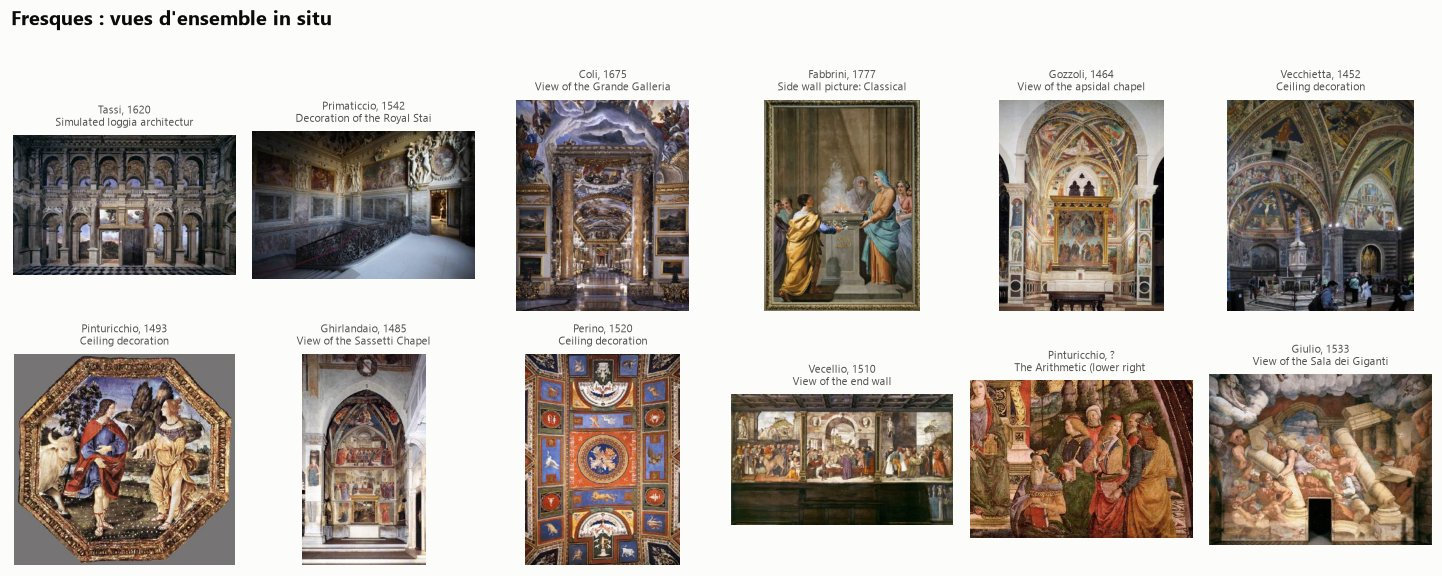

In [9]:
insitu = imgs[(imgs["MEDIUM_FAMILY"] == "Fresque") & ~imgs["IS_DETAIL"]
              & imgs["TITLE"].str.contains(r"view|vault|ceiling|wall|chapel|decoration|apse|dome|cupola", case=False)]
print(f"{len(insitu)} fresques dont le titre évoque une vue d'ensemble (voûte, mur, chapelle…)")
show_grid(insitu.sample(12, random_state=SEED), ncols=6, title="Fresques : vues d'ensemble in situ", name="img_07_fresco_insitu")

### 5.2 « Peintures » dont la technique est une photographie

65 peintures ont pour technique « Photo »


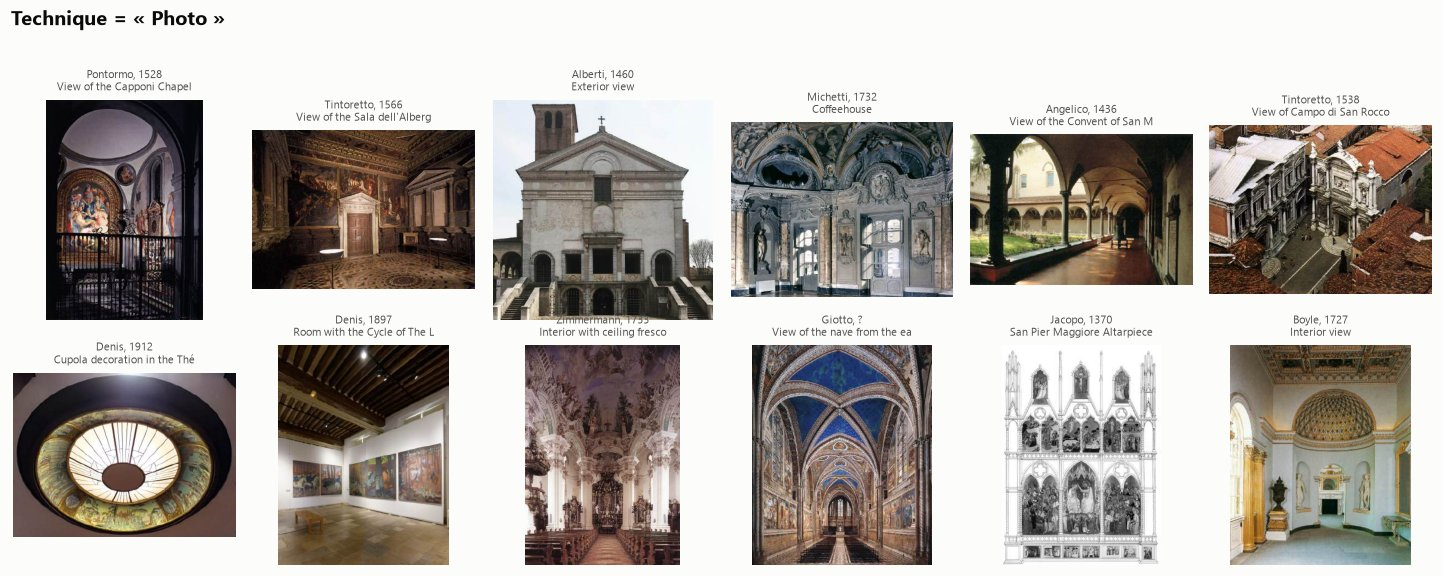

In [10]:
photo = imgs[imgs["MEDIUM"].str.lower().eq("photo")]
print(f"{len(photo)} peintures ont pour technique « Photo »")
show_grid(photo.sample(min(12, len(photo)), random_state=SEED), ncols=6, title="Technique = « Photo »", name="img_08_photo")

### 5.3 Images en niveaux de gris

31 images en mode ['L'] (1 canal)


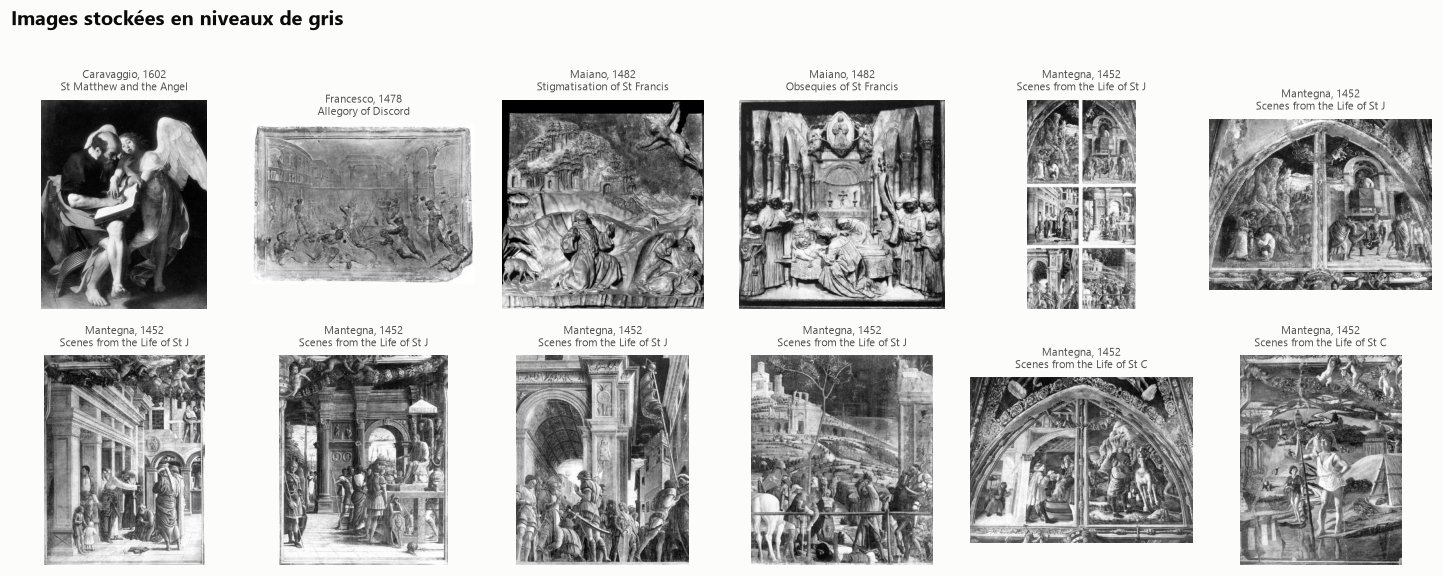

In [11]:
gray = imgs[imgs["mode"] != "RGB"]
print(f"{len(gray)} images en mode {gray['mode'].unique().tolist()} (1 canal)")
show_grid(gray.head(12), ncols=6, title="Images stockées en niveaux de gris", name="img_09_grayscale")

### 5.4 Les plus petites images et les formats extrêmes

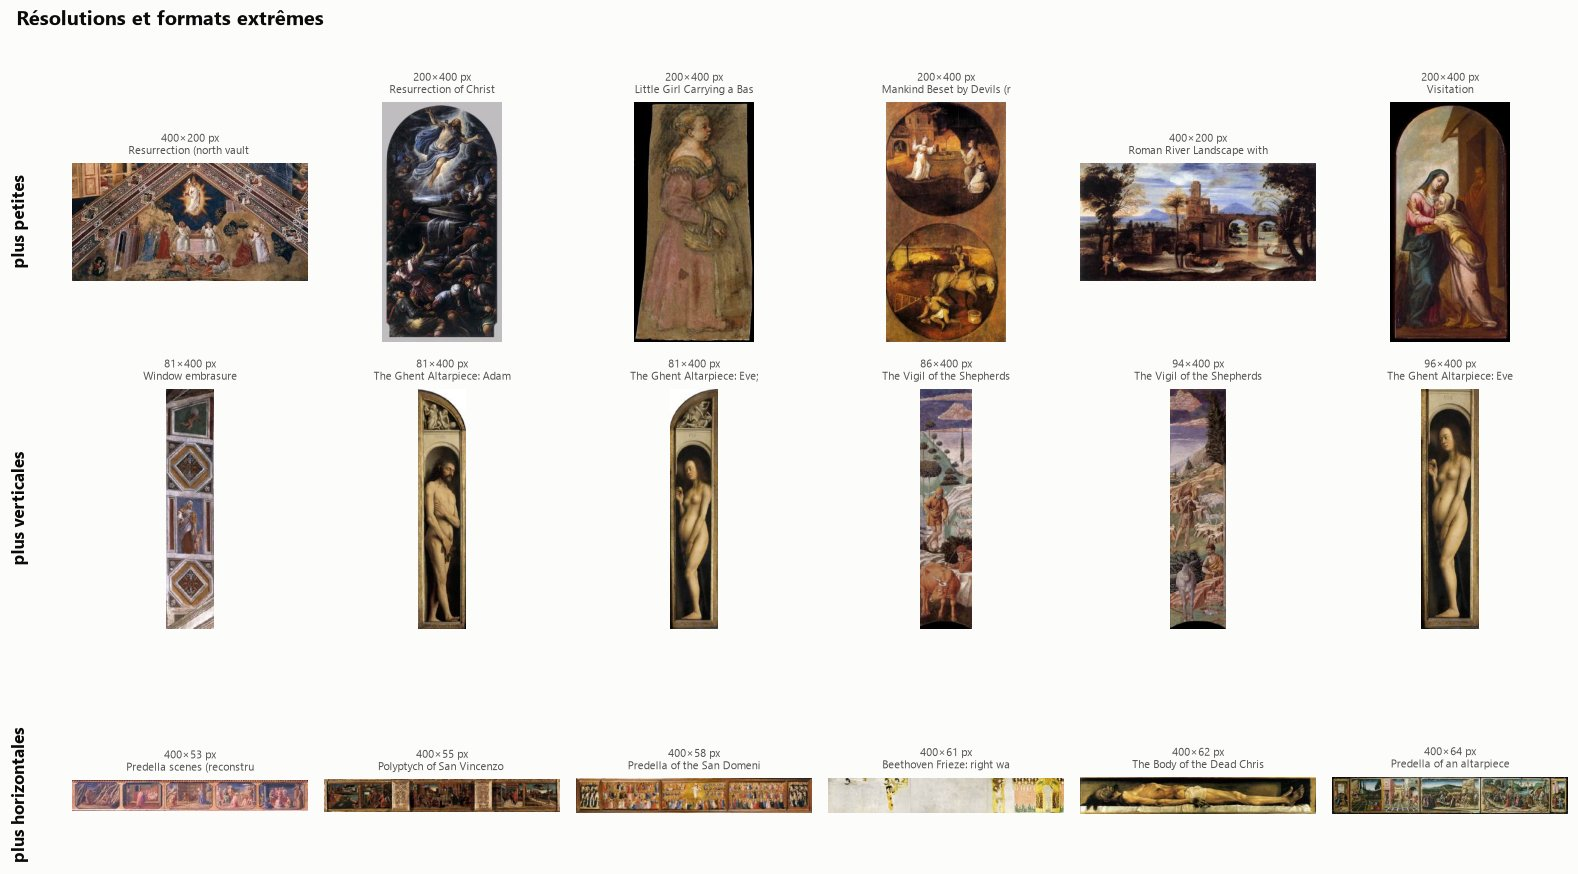

petit côté <  64 px :      5 images (0.0%)
petit côté < 128 px :    165 images (0.5%)
petit côté < 200 px :  1 580 images (4.9%)
petit côté < 256 px :  5 417 images (16.7%)


In [12]:
# "smallest": by pixel count, among non-extreme formats (otherwise they are the same as the most elongated ones)
imgs["PIXELS"] = imgs["width"] * imgs["height"]
small = imgs[imgs["IMG_ASPECT"].between(0.5, 2)].nsmallest(6, "PIXELS")
tall = imgs.nsmallest(6, "IMG_ASPECT")
wide = imgs.nlargest(6, "IMG_ASPECT")
cap_dim = lambda r: f"{r.width:.0f}×{r.height:.0f} px\n{r.TITLE[:26]}"
show_grid([small, tall, wide], ncols=6, cap=cap_dim, size=2.4,
          row_labels=["plus petites", "plus verticales", "plus horizontales"],
          title="Résolutions et formats extrêmes", name="img_10_extremes")

for thr in (64, 128, 200, 256):
    k = (imgs["MIN_SIDE"] < thr)
    print(f"petit côté < {thr:>3} px : {fmt(k.sum()):>6} images ({k.mean():.1%})")

**Observations sur les cas problématiques**

- **Fresques in situ** : 859 fresques ont un titre de vue d'ensemble (voûte, chapelle, mur…). Beaucoup montrent
  l'**architecture** autant que la peinture : colonnes, fenêtres, bancs, visiteurs, perspective plongeante.
- **Technique « Photo » (65 images)** : ce ne sont **pas des peintures** mais des photographies d'architecture
  (façades, cloîtres, intérieurs d'églises, salles de musée). Elles doivent être **exclues**.
- **Niveaux de gris (31 images)** : deux cas bien distincts. D'une part des œuvres **détruites** dont seule subsiste
  une photo noir et blanc — les fresques de Mantegna de la chapelle Ovetari (Padoue, bombardée en 1944) et le premier
  *Saint Matthieu et l'ange* du Caravage (détruit à Berlin en 1945). D'autre part des **reliefs sculptés** (Benedetto da
  Maiano) mal classés en peinture. Dans les deux cas, ce n'est pas l'aspect d'une peinture : à exclure.
- **Résolution** : les images vraiment petites sont celles au format extrême (prédelles, volets). Parmi les formats
  courants, la plus petite fait 200 × 400 px. Seules 165 images (0,5 %) ont un petit côté < 128 px, mais **17 %**
  sont sous 256 px : entraîner en 256×256 imposerait de sur-échantillonner une image sur six.
- **Formats extrêmes** : volets du *Retable de l'Agneau mystique* (ratio 0,2), prédelles (ratio jusqu'à 7,5). Aucune
  stratégie de mise au carré ne les traite correctement (cf. §8).

## 6. Statistiques visuelles sur les 32 437 images

On calcule pour chaque image, réduite en 64×64 (la résolution cible probable du GAN) :

| Mesure | Définition |
|---|---|
| `BRIGHTNESS` | luminance moyenne (0 = noir, 1 = blanc) |
| `CONTRAST` | écart-type de la luminance |
| `SATURATION` | saturation moyenne (espace HSV) |
| `COLORFULNESS` | indice de Hasler & Süsstrunk (2003), sensible à la richesse chromatique |
| `CHROMA_SPREAD` | écart moyen entre canaux R, G, B — proche de 0 pour une image **visuellement monochrome** même stockée en RGB |
| `BORDER_STD`, `BORDER_LUM` | variabilité et luminance des 3 pixels de bord — une faible variabilité signale un **fond uniforme** |

On accumule aussi l'**image moyenne** par genre et par siècle. Les résultats sont mis en cache
(`data/processed/image_stats.csv`) pour ne pas recalculer à chaque exécution.

In [13]:
RES = 64
LUMA = np.array([0.299, 0.587, 0.114], dtype=np.float32)


def image_features(path):
    with Image.open(path) as im:
        im.draft("RGB", (RES * 2, RES * 2))            # reduced-size JPEG decoding: much faster
        small = im.convert("RGB").resize((RES, RES), Image.BILINEAR)
    a = np.asarray(small, dtype=np.float32) / 255
    hsv = np.asarray(small.convert("HSV"), dtype=np.float32) / 255
    lum = a @ LUMA
    rg, yb = a[..., 0] - a[..., 1], 0.5 * (a[..., 0] + a[..., 1]) - a[..., 2]
    b = 3
    border = np.concatenate([a[:b].reshape(-1, 3), a[-b:].reshape(-1, 3), a[:, :b].reshape(-1, 3), a[:, -b:].reshape(-1, 3)])
    k = 6  # the 4 corners: where the background shows around a tondo or an arched panel
    corners = np.concatenate([a[:k, :k], a[:k, -k:], a[-k:, :k], a[-k:, -k:]]).reshape(-1, 3)
    feats = {
        "CORNER_STD": corners.std(axis=0).mean(), "CORNER_LUM": (corners @ LUMA).mean(),
        "BRIGHTNESS": lum.mean(), "CONTRAST": lum.std(), "SATURATION": hsv[..., 1].mean(),
        "COLORFULNESS": np.hypot(rg.std(), yb.std()) + 0.3 * np.hypot(rg.mean(), yb.mean()),
        "CHROMA_SPREAD": (np.abs(a[..., 0] - a[..., 1]) + np.abs(a[..., 1] - a[..., 2])).mean() / 2,
        "BORDER_STD": border.std(axis=0).mean(), "BORDER_LUM": (border @ LUMA).mean(),
        "R": a[..., 0].mean(), "G": a[..., 1].mean(), "B": a[..., 2].mean(),
    }
    return feats, a


if STATS_CACHE.exists() and MEANS_CACHE.exists():
    stats = pd.read_csv(STATS_CACHE)
    means = dict(np.load(MEANS_CACHE))
    print("Statistiques chargées depuis le cache.")
else:
    t0 = time.time()
    rows = imgs[["URL", "PATH", "TYPE", "CENTURY"]].to_dict("records")
    sums, counts, records = {}, {}, []
    with ThreadPoolExecutor(max_workers=8) as pool:
        for r, (feats, arr) in zip(rows, pool.map(lambda r: image_features(r["PATH"]), rows)):
            records.append({"URL": r["URL"], **feats})
            for key in (f"type:{r['TYPE']}", f"century:{int(r['CENTURY'])}", "all"):
                sums[key] = sums.get(key, 0) + arr
                counts[key] = counts.get(key, 0) + 1
    stats = pd.DataFrame(records)
    means = {k: sums[k] / counts[k] for k in sums}
    stats.to_csv(STATS_CACHE, index=False)
    np.savez_compressed(MEANS_CACHE, **means)
    print(f"{fmt(len(stats))} images analysées en {time.time() - t0:.0f} s")

imgs = imgs.merge(stats, on="URL", how="left")
imgs[["BRIGHTNESS", "CONTRAST", "SATURATION", "COLORFULNESS", "CHROMA_SPREAD", "BORDER_STD"]].describe().round(3)

Statistiques chargées depuis le cache.


,BRIGHTNESS,CONTRAST,SATURATION,COLORFULNESS,CHROMA_SPREAD,BORDER_STD
count,32437.000,32437.000,32437.000,32437.000,32437.000,32437.000
mean,0.348,0.182,0.365,0.143,0.075,0.155
std,0.126,0.047,0.117,0.049,0.032,0.064
min,0.026,0.027,0.000,0.000,0.000,0.000
25%,0.253,0.151,0.282,0.109,0.052,0.109
50%,0.340,0.179,0.358,0.138,0.070,0.152
75%,0.435,0.211,0.441,0.171,0.092,0.196
max,0.943,0.408,0.918,0.443,0.283,0.429


### 6.1 Couleur et lumière selon le siècle et la technique

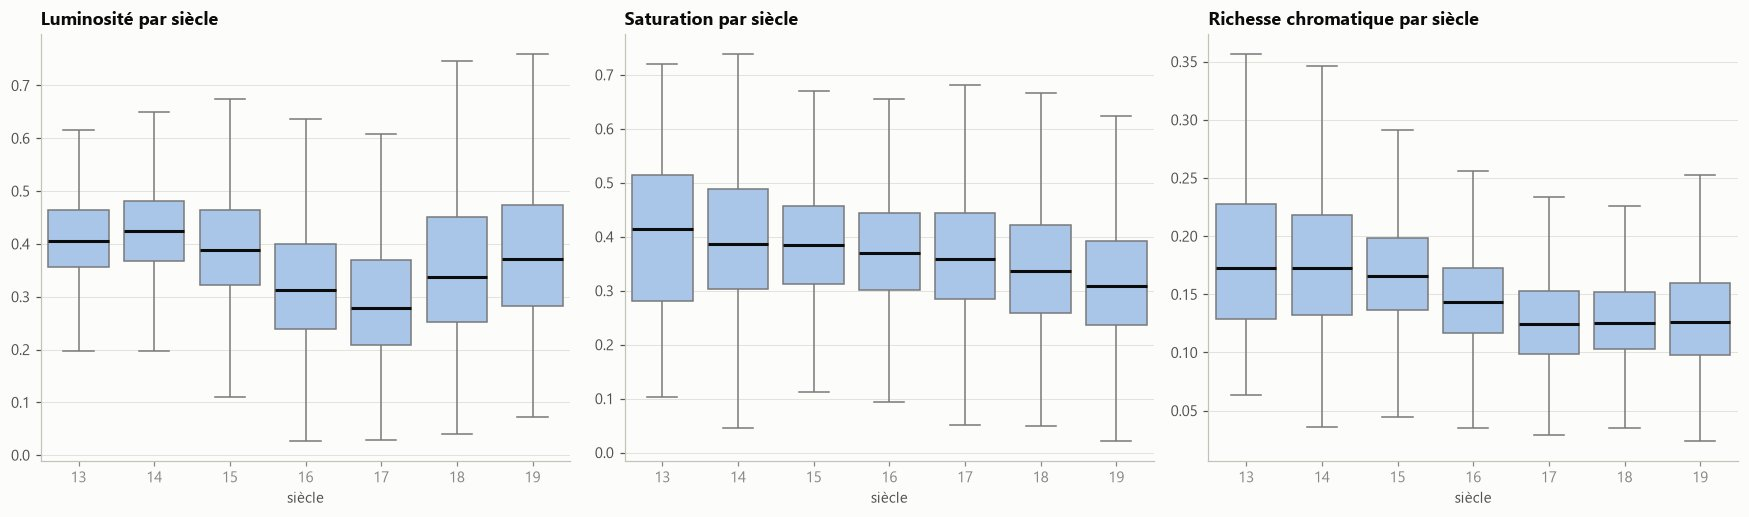

                       BRIGHTNESS  SATURATION  COLORFULNESS  CONTRAST
MEDIUM_FAMILY                                                        
Tempera                     0.393       0.437         0.192     0.179
Fresque                     0.459       0.297         0.134     0.171
Huile                       0.302       0.363         0.132     0.181
Techniques sur papier       0.422       0.259         0.117     0.183


In [14]:
order_c = sorted(imgs.loc[imgs["CENTURY"] >= 13, "CENTURY"].unique())
sub = imgs[imgs["CENTURY"] >= 13]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=False)
for ax, col, lbl in zip(axes, ["BRIGHTNESS", "SATURATION", "COLORFULNESS"], ["Luminosité", "Saturation", "Richesse chromatique"]):
    sns.boxplot(data=sub, x="CENTURY", y=col, order=order_c, ax=ax, color="#9ec5f4", showfliers=False,
                linewidth=1, medianprops={"color": INK, "linewidth": 2})
    ax.set_title(f"{lbl} par siècle"); ax.set_xlabel("siècle"); ax.set_ylabel("")
    ax.grid(axis="x", visible=False)
plt.tight_layout()
save(fig, "img_11_color_by_century")
plt.show()

fams = ["Tempera", "Fresque", "Huile", "Techniques sur papier"]
print(imgs[imgs["MEDIUM_FAMILY"].isin(fams)].groupby("MEDIUM_FAMILY")[["BRIGHTNESS", "SATURATION", "COLORFULNESS", "CONTRAST"]]
      .median().loc[fams].round(3).to_string())

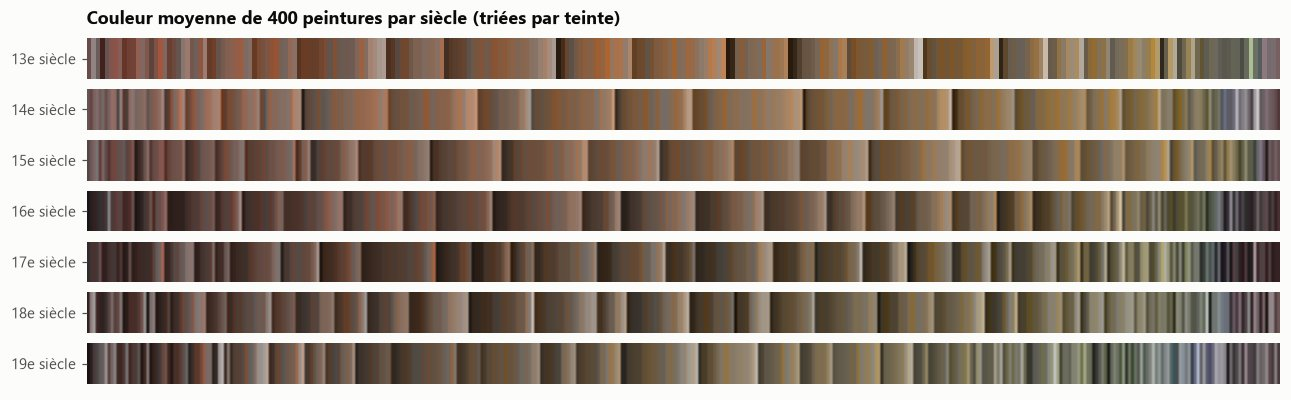

In [15]:
# Mean palette per century: each stripe = one image, sorted by hue, mean colour of the image
fig, ax = plt.subplots(figsize=(14, 4.2))
for i, c in enumerate(order_c):
    s = imgs[imgs["CENTURY"] == c].sample(min(400, (imgs["CENTURY"] == c).sum()), random_state=SEED)
    rgb = s[["R", "G", "B"]].to_numpy()
    hue = np.array([Image.new("RGB", (1, 1), tuple((x * 255).astype(int))).convert("HSV").getpixel((0, 0))[0] for x in rgb])
    rgb = rgb[np.lexsort((s["BRIGHTNESS"].to_numpy(), hue))]
    ax.imshow(rgb[None, :, :], extent=(0, 1, i + 0.1, i + 0.9), aspect="auto")
ax.set_xlim(0, 1); ax.set_ylim(len(order_c), 0)
ax.set_yticks(np.arange(len(order_c)) + 0.5, [f"{c}e siècle" for c in order_c])
ax.set_xticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Couleur moyenne de 400 peintures par siècle (triées par teinte)")
save(fig, "img_12_palette_by_century")
plt.show()

### 6.2 L'image moyenne

Moyenner toutes les images d'un groupe pixel par pixel (après redimensionnement en 64×64) révèle la **composition
typique** : c'est une première intuition de ce que le GAN apprendra en priorité.

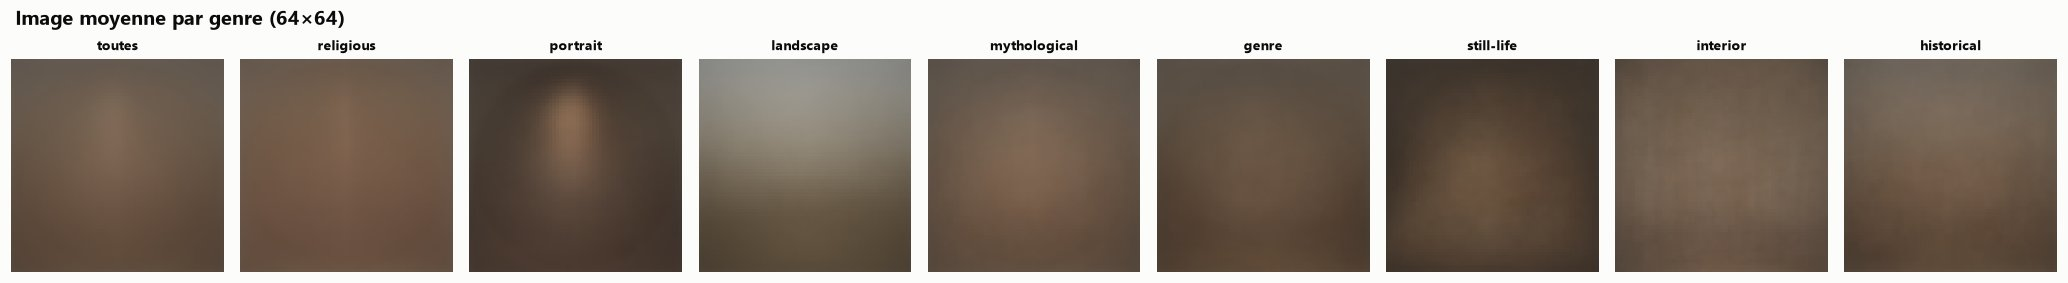

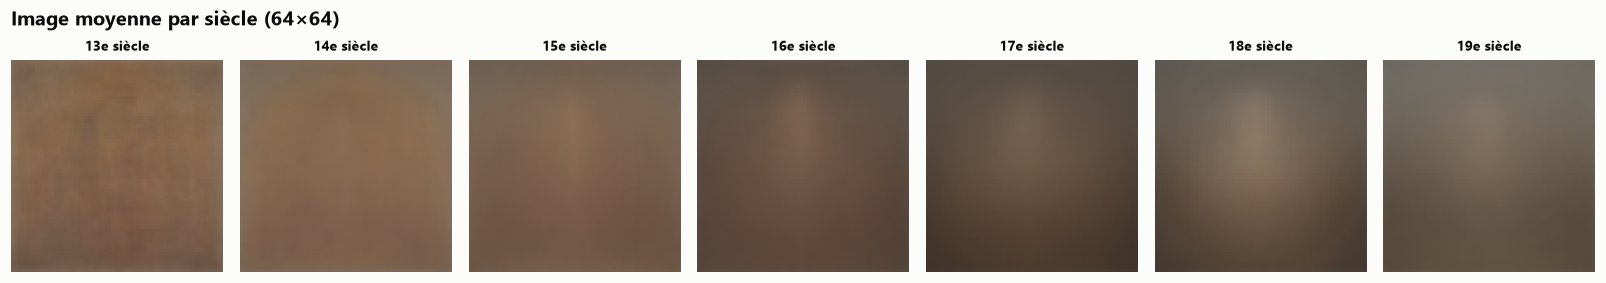

In [16]:
types = ["religious", "portrait", "landscape", "mythological", "genre", "still-life", "interior", "historical"]
keys = ["all"] + [f"type:{t}" for t in types]
labels = ["toutes"] + types
fig, axes = plt.subplots(1, len(keys), figsize=(2.1 * len(keys), 2.6))
for ax, k, lbl in zip(axes, keys, labels):
    ax.imshow(np.clip(means[k], 0, 1)); ax.axis("off"); ax.set_title(lbl, fontsize=9, loc="center")
fig.suptitle("Image moyenne par genre (64×64)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "img_13_mean_by_type")
plt.show()

keys = [f"century:{c}" for c in order_c]
fig, axes = plt.subplots(1, len(keys), figsize=(2.1 * len(keys), 2.6))
for ax, k, c in zip(axes, keys, order_c):
    ax.imshow(np.clip(means[k], 0, 1)); ax.axis("off"); ax.set_title(f"{c}e siècle", fontsize=9, loc="center")
fig.suptitle("Image moyenne par siècle (64×64)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "img_14_mean_by_century")
plt.show()

### 6.3 Images monochromes et fonds uniformes

Un premier essai avec un seuil absolu sur `CHROMA_SPREAD` attrapait aussi des **portraits simplement très sombres**
(un pixel presque noir a mécaniquement des canaux proches). On rapporte donc l'écart entre canaux à la luminosité :
`CHROMA_REL = CHROMA_SPREAD / BRIGHTNESS`.

De même, un bord uniforme peut signifier deux choses opposées : un **fond sombre** peint (portraits ténébristes)
— qui fait partie de l'œuvre — ou un **fond clair de studio** autour d'un panneau de forme irrégulière — qui n'en
fait pas partie. On les distingue par la luminance du bord.

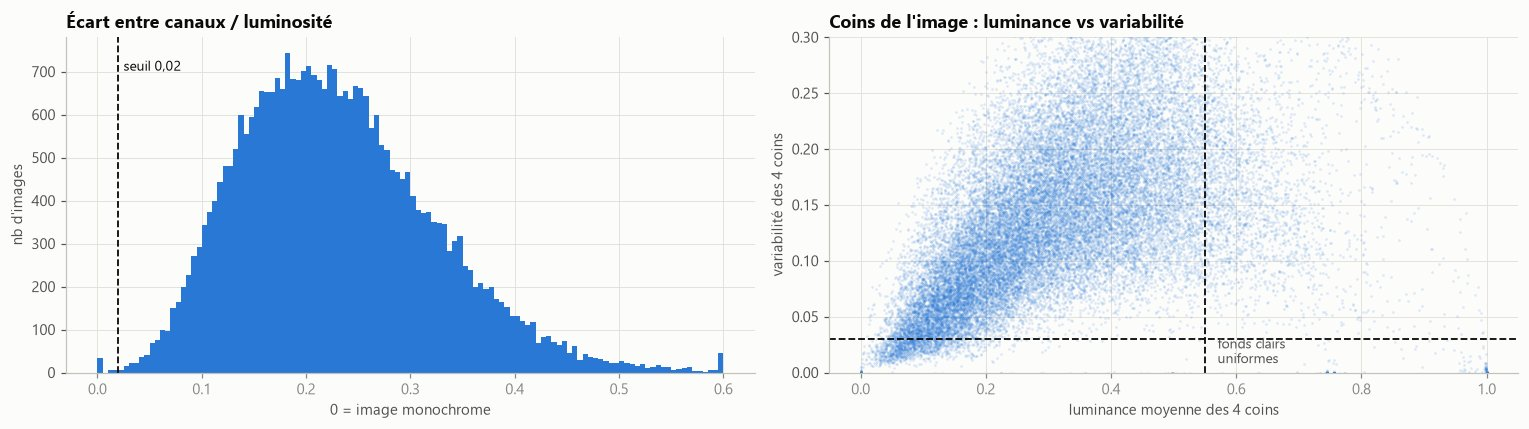

Images monochromes (écart relatif < 0,02) : 45 (0.14%), dont 31 stockées en niveaux de gris
Bord uniforme sombre (fond peint)         : 336 (1.0%)
Coins uniformes clairs (fond de studio)   : 401 (1.2%), dont 115 tondi identifiés au catalogue

Techniques des images monochromes (brutes, catalogue) :
MEDIUM
fresco         13
marble          5
bronze          4
pen             4
engraving       3
oil             2
stucco          2
limestone       2
woodcut         2
lead-pencil     1


In [17]:
imgs["CHROMA_REL"] = imgs["CHROMA_SPREAD"] / imgs["BRIGHTNESS"].clip(lower=0.05)
mono = imgs[imgs["CHROMA_REL"] < 0.02]
flat_dark = imgs[(imgs["BORDER_STD"] < 0.03) & (imgs["BORDER_LUM"] < 0.2)]
flat_light = imgs[(imgs["CORNER_STD"] < 0.03) & (imgs["CORNER_LUM"] > 0.55)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(imgs["CHROMA_REL"].clip(upper=0.6), bins=120, color=MAIN)
axes[0].axvline(0.02, color=INK, lw=1.2, ls="--"); axes[0].text(0.025, axes[0].get_ylim()[1] * 0.9, "seuil 0,02", fontsize=9)
axes[0].set_title("Écart entre canaux / luminosité"); axes[0].set_xlabel("0 = image monochrome"); axes[0].set_ylabel("nb d'images")
axes[1].scatter(imgs["CORNER_LUM"], imgs["CORNER_STD"], s=3, alpha=0.15, color=MAIN, linewidths=0)
axes[1].axhline(0.03, color=INK, lw=1.2, ls="--"); axes[1].axvline(0.55, color=INK, lw=1.2, ls="--")
axes[1].text(0.57, 0.005, "fonds clairs\nuniformes", fontsize=9, color=INK2, va="bottom")
axes[1].set_ylim(0, 0.3)
axes[1].set_title("Coins de l'image : luminance vs variabilité")
axes[1].set_xlabel("luminance moyenne des 4 coins"); axes[1].set_ylabel("variabilité des 4 coins")
plt.tight_layout()
save(fig, "img_15_mono_border_hist")
plt.show()

print(f"Images monochromes (écart relatif < 0,02) : {fmt(len(mono))} ({len(mono) / len(imgs):.2%}), "
      f"dont {(mono['mode'] != 'RGB').sum()} stockées en niveaux de gris")
print(f"Bord uniforme sombre (fond peint)         : {fmt(len(flat_dark))} ({len(flat_dark) / len(imgs):.1%})")
print(f"Coins uniformes clairs (fond de studio)   : {fmt(len(flat_light))} ({len(flat_light) / len(imgs):.1%}), "
      f"dont {flat_light['IS_TONDO'].sum()} tondi identifiés au catalogue")
print("\nTechniques des images monochromes (brutes, catalogue) :")
print(mono["MEDIUM"].str.lower().str.split().str[0].value_counts().head(10).to_string())

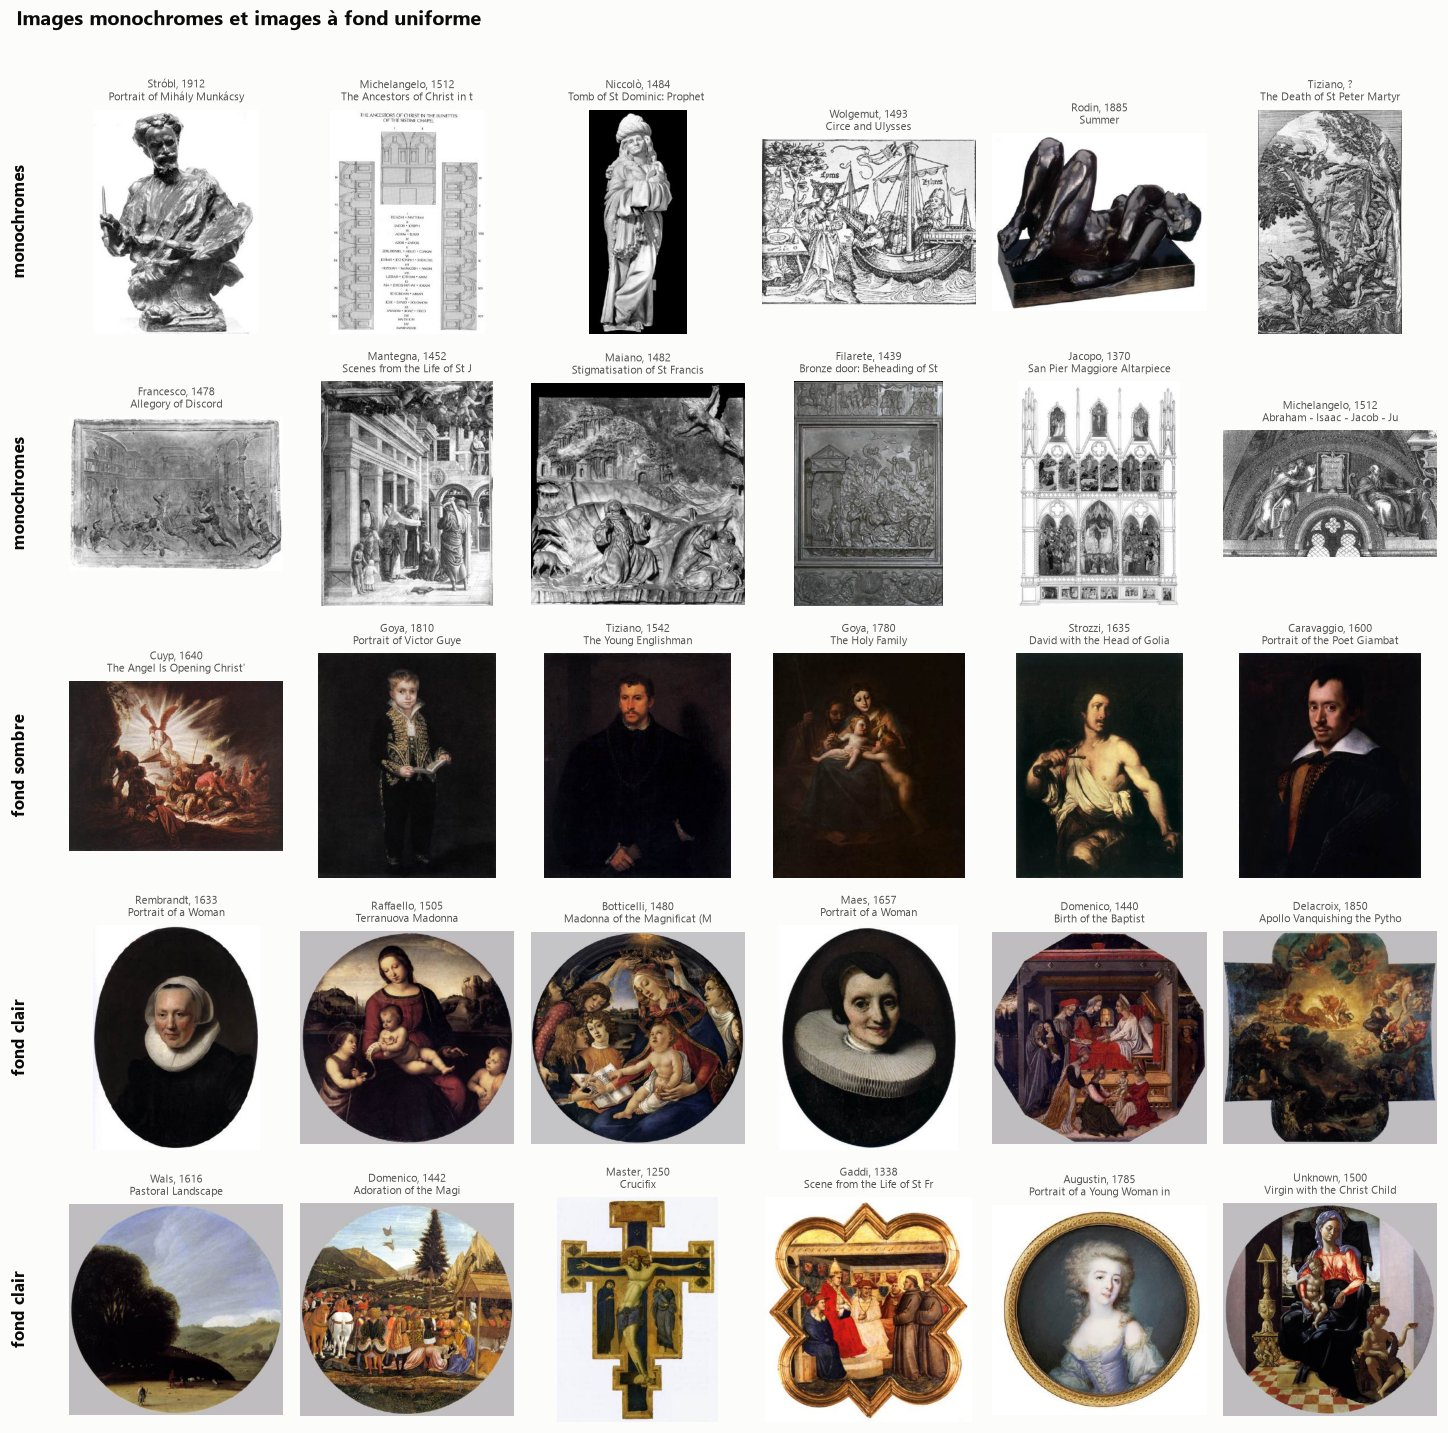

In [18]:
m12, l12 = mono.sample(12, random_state=SEED), flat_light.sample(12, random_state=SEED)   # draws without duplicates
show_grid([m12.iloc[:6], m12.iloc[6:], flat_dark.sample(6, random_state=SEED), l12.iloc[:6], l12.iloc[6:]],
          row_labels=["monochromes", "monochromes", "fond sombre", "fond clair", "fond clair"],
          title="Images monochromes et images à fond uniforme", name="img_16_mono_border")

**Observations sur les statistiques visuelles**

- **La lumière suit l'histoire de l'art** : les XIIIᵉ-XIVᵉ siècles sont les plus clairs (luminosité médiane 0,41-0,42 :
  fonds d'or, fresques), puis la peinture s'assombrit jusqu'au **XVIIᵉ siècle (0,28)**, sommet du clair-obscur
  caravagesque et hollandais, avant de s'éclaircir à nouveau (0,37 au XIXᵉ).
- **La saturation baisse régulièrement** du XIIIᵉ (0,41) au XIXᵉ siècle (0,31), et la richesse chromatique suit
  (0,17 → 0,13) : pigments purs et or des primitifs contre tons rompus et glacis de l'huile.
- Par technique : la **tempera** est la plus saturée et colorée, la **fresque** la plus claire mais délavée,
  l'**huile** la plus sombre (luminosité médiane 0,30).
- **Les images moyennes** donnent la composition typique : le **portrait** fait apparaître un ovale clair (visage)
  centré dans le tiers supérieur sur fond sombre ; le **paysage** une bande de ciel clair au-dessus d'un sol sombre ;
  les autres genres une masse centrale plus claire. L'image moyenne globale est un **brun-ocre** : c'est la couleur vers
  laquelle un GAN en début d'entraînement convergera.
- **Monochromes (45 images, 0,14 %)** : sculptures, gravures, dessins, photos d'œuvres détruites, quelques grisailles.
  Presque aucune n'est une peinture au sens visuel → à exclure.
- **Fonds sombres uniformes (336 images, 1 %)** : ce sont des portraits et scènes ténébristes. Le fond fait partie de
  l'œuvre → à conserver.
- **Coins clairs uniformes (401 images, 1,2 %)** : tondi, ovales, panneaux chantournés photographiés sur **fond gris
  ou blanc de studio**. Ce fond ne fait pas partie de l'œuvre ; le GAN apprendrait à générer des coins gris. Volume
  faible : les exclure est le plus simple.

## 7. Le format réel des images

L'EDA a estimé le format des tableaux à partir des dimensions du catalogue (`HEIGHT_CM × WIDTH_CM`). Mais la
**photographie** peut inclure un cadre, un mur, ou au contraire recadrer l'œuvre. Comparons les deux ratios.

22 855 peintures ont à la fois des dimensions au catalogue et une image
Ratio de l'image à ±10 % du ratio du catalogue : 90.0%
Corrélation (log-ratios) : 0.900


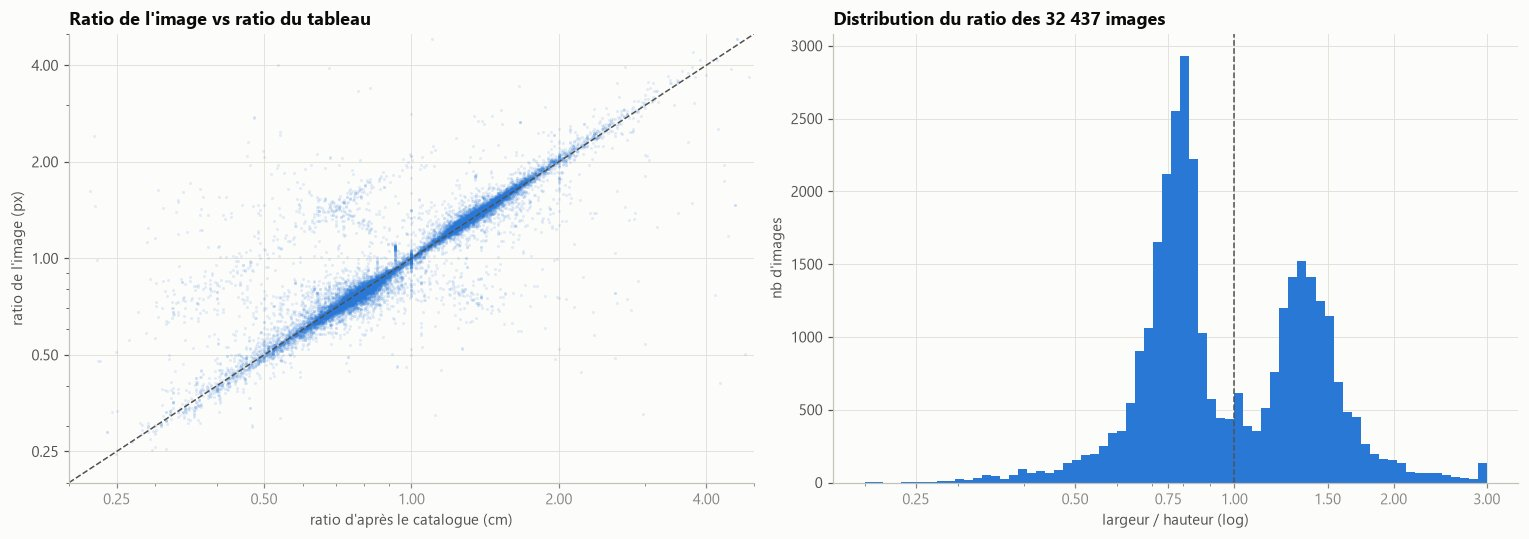

Perte médiane d'un recadrage centré en carré (images réelles) : 24.8%
Images perdant plus de 30 % : 31.4%


In [19]:
both = imgs.dropna(subset=["ASPECT"]).copy()
both = both[both["ASPECT"].between(0.1, 10)]
both["LOG_GAP"] = np.log(both["IMG_ASPECT"] / both["ASPECT"])
agree = (both["LOG_GAP"].abs() < np.log(1.10)).mean()
print(f"{fmt(len(both))} peintures ont à la fois des dimensions au catalogue et une image")
print(f"Ratio de l'image à ±10 % du ratio du catalogue : {agree:.1%}")
print(f"Corrélation (log-ratios) : {np.corrcoef(np.log(both['IMG_ASPECT']), np.log(both['ASPECT']))[0, 1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(both["ASPECT"], both["IMG_ASPECT"], s=4, alpha=0.12, color=MAIN, linewidths=0)
ax.plot([0.2, 5], [0.2, 5], color=INK2, ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.2, 5); ax.set_ylim(0.2, 5)
for a in (ax.xaxis, ax.yaxis):
    a.set_major_formatter(mtick.ScalarFormatter()); a.set_minor_formatter(mtick.NullFormatter())
ax.set_xticks([0.25, 0.5, 1, 2, 4]); ax.set_yticks([0.25, 0.5, 1, 2, 4])
ax.set_xlabel("ratio d'après le catalogue (cm)"); ax.set_ylabel("ratio de l'image (px)")
ax.set_title("Ratio de l'image vs ratio du tableau")

ax = axes[1]
ax.hist(imgs["IMG_ASPECT"].clip(0.2, 3), bins=np.logspace(np.log10(0.2), np.log10(3), 70), color=MAIN)
ax.set_xscale("log"); ax.set_xticks([0.25, 0.5, 0.75, 1, 1.5, 2, 3])
ax.xaxis.set_major_formatter(mtick.ScalarFormatter()); ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.axvline(1, color=INK2, ls="--", lw=1)
ax.set_title("Distribution du ratio des 32 437 images"); ax.set_xlabel("largeur / hauteur (log)"); ax.set_ylabel("nb d'images")
plt.tight_layout()
save(fig, "img_17_aspect_image_vs_catalog")
plt.show()

crop_loss = 1 - np.minimum(imgs["IMG_ASPECT"], 1 / imgs["IMG_ASPECT"])
print(f"Perte médiane d'un recadrage centré en carré (images réelles) : {crop_loss.median():.1%}")
print(f"Images perdant plus de 30 % : {(crop_loss > 0.3).mean():.1%}")

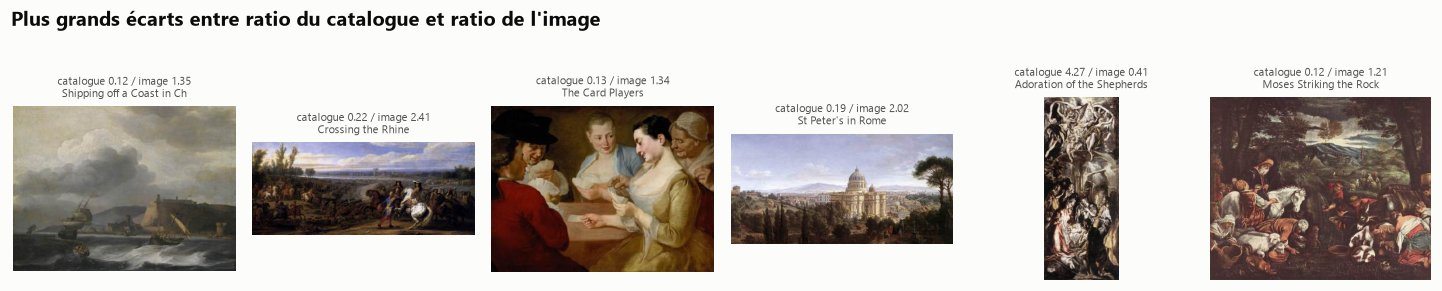

In [20]:
# Largest disagreements: what does the photo show?
gap = both.reindex(both["LOG_GAP"].abs().sort_values(ascending=False).index).head(6)
show_grid(gap, ncols=6, cap=lambda r: f"catalogue {r.ASPECT:.2f} / image {r.IMG_ASPECT:.2f}\n{r.TITLE[:26]}",
          title="Plus grands écarts entre ratio du catalogue et ratio de l'image", name="img_18_aspect_gaps")

**Observations** — le ratio des images concorde bien avec les dimensions du catalogue (**90 %** des images à ±10 %,
corrélation 0,90). Les plus gros écarts viennent d'**erreurs du catalogue** (`102 x 12 cm` pour une toile manifestement
horizontale) et non des images : c'est donc le **ratio de l'image** qui fait foi pour le preprocessing.

Sur les images réelles, un recadrage centré en carré fait perdre en médiane **25 % de la surface**, et plus de 30 %
pour **près d'une image sur trois**. À l'inverse, 88 % des images ont un ratio compris entre 0,6 et 1,67 et 95 %
entre 0,5 et 2.

## 8. Démonstration : que voit le GAN en 64×64 ?

Trois stratégies pour ramener une image rectangulaire au carré 64×64 attendu par un DCGAN :

- **recadrage centré** (*center crop*) : on garde le carré central → aucune déformation, mais on perd les bords ;
- **padding** (*letterbox*) : on ajoute des bandes pour compléter le carré → rien n'est perdu, mais le GAN apprendra
  aussi à générer des bandes ;
- **étirement** (*resize*) : on force le carré → rien n'est perdu, mais les proportions sont déformées.

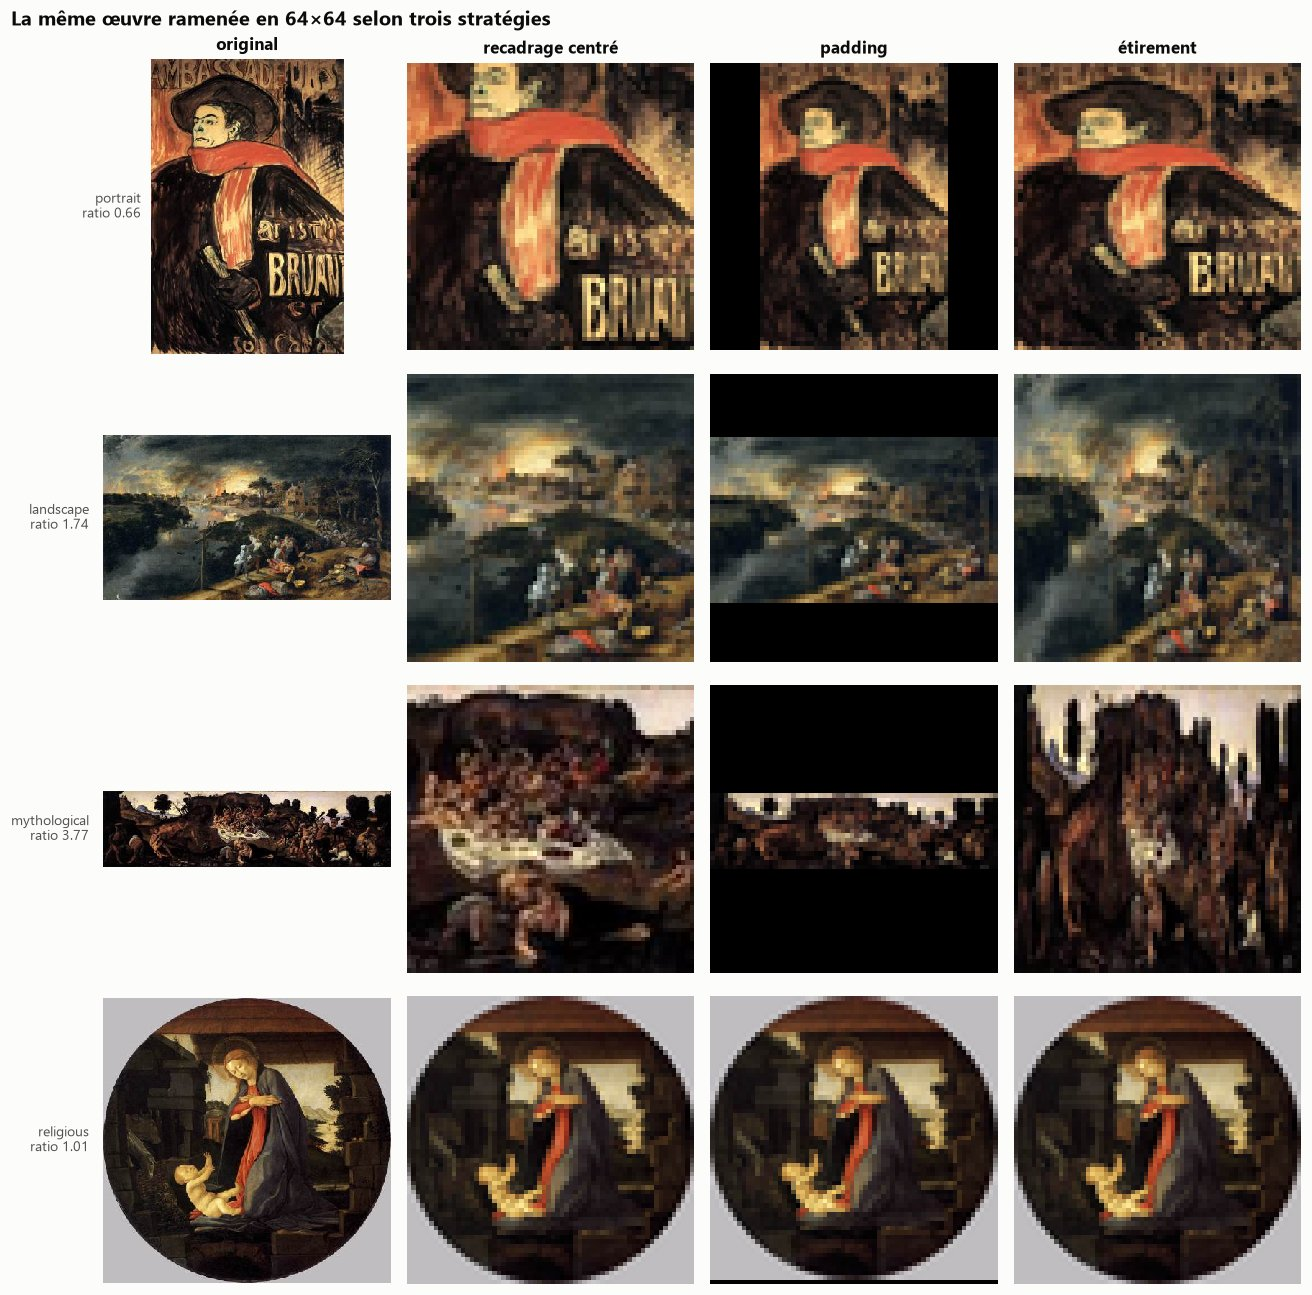

In [21]:
def center_crop(im, size):
    return ImageOps.fit(im, (size, size), Image.LANCZOS, centering=(0.5, 0.5))


def letterbox(im, size, fill=(0, 0, 0)):
    return ImageOps.pad(im, (size, size), Image.LANCZOS, color=fill)


def stretch(im, size):
    return im.resize((size, size), Image.LANCZOS)


examples = pd.concat([
    imgs[(imgs["TYPE"] == "portrait") & imgs["IMG_ASPECT"].between(0.6, 0.7)].sample(1, random_state=1),
    imgs[(imgs["TYPE"] == "landscape") & imgs["IMG_ASPECT"].between(1.6, 1.9)].sample(1, random_state=1),
    imgs[imgs["IMG_ASPECT"] > 3].sample(1, random_state=3),
    imgs[imgs["IS_TONDO"] & ~imgs["IS_DETAIL"]].sample(1, random_state=1),
])
methods = [("original", None), ("recadrage centré", center_crop), ("padding", letterbox), ("étirement", stretch)]

fig, axes = plt.subplots(len(examples), len(methods), figsize=(12, 3 * len(examples)))
for i, (_, r) in enumerate(examples.iterrows()):
    with Image.open(r.PATH) as im:
        im = im.convert("RGB")
        for j, (name, fn) in enumerate(methods):
            ax = axes[i, j]
            ax.imshow(im if fn is None else fn(im, 64), interpolation="nearest")
            ax.axis("off")
            if i == 0:
                ax.set_title(name, fontsize=11, loc="center")
    axes[i, 0].text(-0.05, 0.5, f"{r.TYPE}\nratio {r.IMG_ASPECT:.2f}", transform=axes[i, 0].transAxes,
                    ha="right", va="center", fontsize=9, color=INK2)
fig.suptitle("La même œuvre ramenée en 64×64 selon trois stratégies", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "img_19_resize_strategies")
plt.show()

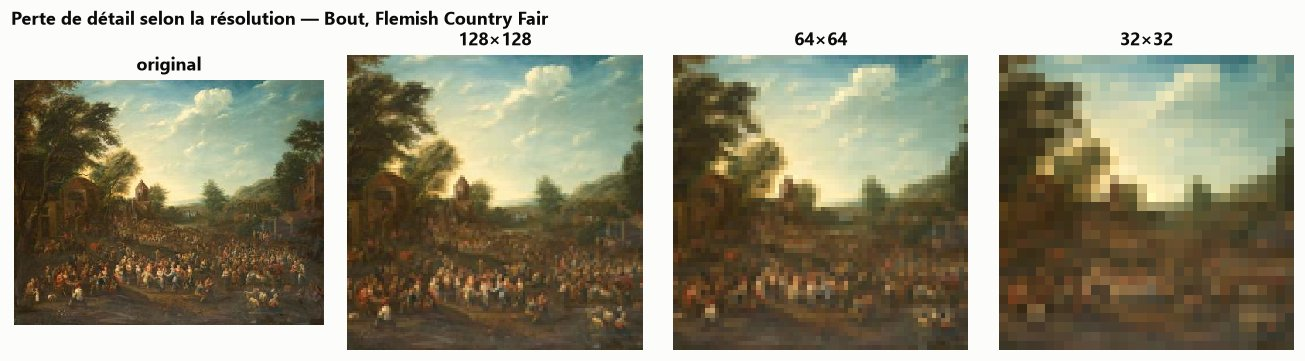

In [22]:
# Same comparison for the resolution: 32, 64, 128 px (centre crop)
r = imgs[(imgs["TYPE"] == "genre") & ~imgs["IS_DETAIL"] & imgs["IMG_ASPECT"].between(0.9, 1.4)].sample(1, random_state=7).iloc[0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.3))
with Image.open(r.PATH) as im:
    im = im.convert("RGB")
    for ax, s in zip(axes, [None, 128, 64, 32]):
        ax.imshow(im if s is None else center_crop(im, s), interpolation="nearest"); ax.axis("off")
        ax.set_title("original" if s is None else f"{s}×{s}", loc="center")
fig.suptitle(f"Perte de détail selon la résolution — {short_author(r.AUTHOR)}, {r.TITLE[:40]}",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save(fig, "img_20_resolution")
plt.show()

**Observations**

- **Recadrage centré** : aucune déformation, texture préservée — mais le portrait vertical perd le haut de la tête et
  les mains, et la prédelle perd l'essentiel de sa composition.
- **Padding** : l'œuvre est entière mais les **bandes noires** occupent une large part du carré (plus de 70 % pour
  la prédelle). Le GAN apprendrait à générer ces bandes, et elles seraient de largeur variable selon l'image.
- **Étirement** : tout est conservé, mais les proportions sont faussées. Supportable pour un ratio proche de 1,
  grotesque pour la prédelle (figures étirées en hauteur).
- **Tondo** : les trois méthodes donnent le même résultat… avec les **coins gris** du fond de studio.
- **Résolution** : en 32×32, la scène est illisible ; en **64×64**, la composition (ciel, masses, foule) reste lisible
  mais les personnages deviennent des taches ; en **128×128**, les figures redeviennent identifiables.

## 9. Synthèse : incidences sur le preprocessing

### Ce que l'on observe

1. Les images sont **propres techniquement** : 32 437 JPEG valides, 400 px de grand côté, quasiment toutes en RGB.
2. Mais le dataset **n'est pas un ensemble de tableaux homogènes** : il mêle œuvres entières et détails, polyptyques
   avec leurs cadres, fresques photographiées dans leur architecture, photos de bâtiments, sculptures et gravures mal
   classées, panneaux détourés sur fond de studio.
3. Les formats sont **majoritairement rectangulaires** et bimodaux (vertical ≈ 0,8, horizontal ≈ 1,3) ; seuls 4 %
   des tableaux sont carrés.
4. La **palette** dépend fortement de l'époque et de la technique : or et couleurs pures des primitifs, clair-obscur
   du XVIIᵉ, tons clairs du XIXᵉ. L'image moyenne du corpus est un brun-ocre sombre.

### Pipeline de preprocessing recommandé

| Étape | Règle | Effet estimé |
|---|---|---|
| 1. Retirer les non-peintures | `MEDIUM == "Photo"` et images monochromes (`CHROMA_REL < 0,02`) | −65 et −45 images |
| 2. Retirer les quasi-doublons | `IS_NEAR_DUP` (détails, vues multiples) | −18 % |
| 3. Retirer les fonds de studio | coins clairs uniformes (`CORNER_STD < 0,03`, `CORNER_LUM > 0,55`) | −1,2 % |
| 4. Retirer les formats extrêmes | garder `0,5 ≤ ratio ≤ 2` (ou 0,6-1,67 pour être plus strict) | −5 % (−12 %) |
| 5. (Option) Retirer les vues in situ | fresques dont le titre évoque une vue d'ensemble | −859 max. |
| 6. Mise au carré | **recadrage centré** pour l'entraînement ; en augmentation, **recadrage aléatoire** plutôt que centré | — |
| 7. Redimensionnement | **64×64** pour un premier DCGAN, 128×128 ensuite (0,5 % des images seulement sous 128 px) | — |
| 8. Couleur | conversion en RGB (31 images en niveaux de gris, de toute façon exclues à l'étape 1) | — |
| 9. Normalisation | pixels dans `[-1, 1]` pour une sortie `tanh` du générateur | — |
| 10. Augmentation | **flip horizontal** uniquement (pas de rotation ni de variation de couleur, qui dénatureraient les œuvres) | ×2 |

Après ces filtres, il reste **de l'ordre de 25 000 peintures**, largement assez pour un DCGAN.

**Choix à trancher avant l'entraînement** : entraîner sur tout le corpus filtré, ou sur un **sous-corpus homogène**
(par exemple les portraits, ou les paysages, ou l'huile des XVIIᵉ-XIXᵉ siècles). Les images moyennes montrent que
portraits et paysages ont une structure très régulière : ce sont les candidats les plus faciles pour obtenir des
générations convaincantes avec un petit GAN.